<a href="https://colab.research.google.com/github/NancyEugene/smart-finance-assistant/blob/main/smart_finance_assistant_nancyeugene.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Initial Setup

In [10]:
!pip install gradio pandas hands-on-ai

# Importing core libraries
import pandas as pd
import numpy as np
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

print("📦 Core libraries loaded successfully!")
print(f"Pandas version: {pd.__version__}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.7/143.7 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.2/178.2 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.0/25.0 MB 26.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.0/253.0 kB 22.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 360.7/360.7 kB 31.9 MB/s eta 0:00:00
  Attempting uninstall: jiter
    Found existing installation: jiter 0.15.0
    Uninstalling jiter-0.15.0:
      Successfully uninstalled jiter-0.15.0
📦 Core libraries loaded successfully!
Pandas version: 2.2.2


# Hands-On AI configuration

In [9]:
import os

os.environ['HANDS_ON_AI_SERVER'] = 'http://localhost:11434'
os.environ['HANDS_ON_AI_MODEL'] = 'llama3'
os.environ['HANDS_ON_AI_API_KEY'] = 'local-ollama'

print("✅ Hands-on-AI environment variables configured successfully!")


✅ Hands-on-AI environment variables configured successfully!


# Connection Test

In [4]:
# Install zstd if not present (required for Ollama extraction)
!command -v zstd >/dev/null || sudo apt-get install zstd -y

# Install Ollama if not already present
!command -v ollama >/dev/null || curl -fsSL https://ollama.com/install.sh | sh

import subprocess
import time
import urllib.request

# Start Ollama as a background process
subprocess.Popen(
    ["ollama", "serve"],
    stdout=subprocess.DEVNULL,
    stderr=subprocess.DEVNULL
)

# Give it a few seconds to fully start up
print("⏳ Starting Ollama server...")
time.sleep(5)

# Confirm it's up
try:
    urllib.request.urlopen("http://localhost:11434", timeout=5)
    print("✅ Ollama is now running!")

    # Pull the llama3.2 model, as the hands-on-ai library seems to be looking for it
    print("⏳ Pulling llama3.2 model...")
    subprocess.run(["ollama", "pull", "llama3.2"], check=True)
    print("✅ llama3.2 model pulled successfully!")

except Exception as e:
    print(f"❌ Still not reachable or model pull failed: {e}")
    print("   Try increasing the sleep time to 10 seconds and re-run, or check Ollama logs.")

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  zstd
0 upgraded, 1 newly installed, 0 to remove and 1 not upgraded.
Need to get 603 kB of archives.
After this operation, 1,695 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/main amd64 zstd amd64 1.4.8+dfsg-3build1 [603 kB]
Fetched 603 kB in 0s (3,845 kB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package zstd.
(Reading database ... 118212 files and directories currently 

Foundation Skills

In [ ]:
import pandas as pd
df = pd.read_csv('/content/Smart-Finance Assistant TransactionData.csv')
df.head()

,Date,Amount,Category,Description
0,4/3/2026,$(10.50),Food,Intermart Weekly Shop
1,4/4/2026,"$2,500.00",Income,Monthly Salary
2,4/6/2026,$(94.95),Entertainment,Concert Tickets - Davido
3,4/7/2026,"$1,500.00",Housing,Monthly Rent
4,4/11/2026,$(125.00),Food,Winners Weekly Shop


# Step 1: Problem Definition

My finance problem is Spending Pattern Analysis that targets to help small business owners, students/recent graduates and high earners who are not yet rich so that they can help manage their savings identify their spending triggers,  before they happen and discover their pattern analysis that is, where their money actually goes.

# Step 2: Input and Output

**Input**


*   CSV with Transaction data (Date, Amount, Category, Description)
*   AI Chatbot Prompts
*   Amount Saved per month, Saving Goal and Amount Saved Currently.




**Output**


*   Remaining time to reach user's saving goal
*   Category with the highest spending
*   Financial Advice
*   Warnings to manage spending on categories with the highest amount









# Step 3: Work the Problem by Hand
Business Calculation

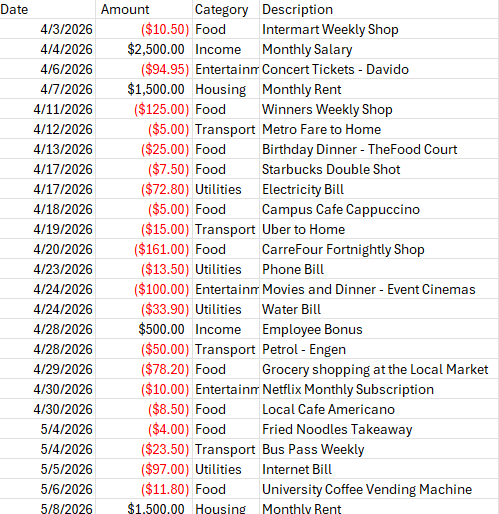

Manual Calculations:

Total Spending: $952.15
Total Income: $6,000
By Category: Food - $436.5, Entertainment - $204.95, Transport - $93.5, Utilities - $217.2
Average Transaction: $45.34
Insight: Food represents 45.8% of positive spending

# Step 4: Pseudocode

Initial Pseudocode

     1. The app displays a Welcome message to the user.

     2. Load CSV file
    Open, read and clean CSV file "finance assistant sample data.csv"

        Each row contains:
            Date, Amount, Category, Description

     3. The app processes transactions by recording amount spent, add the amount to total spending, calculate average spending, group the spending and generate counts per category, for each record in the transactions.


     4. Identify highest spending category and spending weights within each category.
    
     5. Generate insights by displaying the following
     "----- FINANCIAL SUMMARY -----"
     "Total Spending:"
     "Category with the highest spending:"
     "Spending in each category with their percentages:"
     
     6. Give Smart recommendations per category

     7. Prompt user to input: Target Goal, Available Savings, Planned Monthly contributions.

     8. Calculate Savings Timeline.



Reviewed Pseudocode

1. Welcome Screen Display "Welcome to Smart Finance Assistant"

2. Load & Clean CSV
   Open "finance assistant sample data.csv"
   Remove currency symbols and convert Amount to float
   Filter out positive amounts (Income) into a separate variable if needed
   Flag and clean missing fields (e.g., empty descriptions)

3. Process Data & Map Frameworks
   For each transaction:
       Add to Total_Spending
       Track Category_Totals and Category_Counts
       Classify Category into "Need" or "Want" (e.g., Rent=Need, Shopping=Want)
   
   Determine Date Range of CSV (to calculate true monthly averages)

4. Calculate Weights and Metrics
   Calculate Overall_Average_Monthly_Spending
   For each category:
       Calculate Spending_Weight = (Category_Total / Total_Spending) * 100

5. Generate Financial Summary
   Display "----- FINANCIAL SUMMARY -----"
   Display "Total Spending: $" + Total_Spending
   Display "Macro Breakdown: Needs vs Wants Ratio"
   Display "Highest Spending Category: " + Top_Category
   Display "Category Weights & Percentages:"
   Print Category_Totals and Spending_Weights

6. Execute Smart Recommendations
   If "Wants" percentage > 30%:
       Recommend specific Variable categories to cut back on
   Identify high-frequency micro-transactions and flag them

7. Financial Goal Mapping
   Prompt user for: Target Goal ($ Amount), Available Savings, Planned Monthly Contribution

8. Calculate Savings Timeline (with Reality Check)
   Calculate Remaining_Goal = Target Goal - Available Savings
   
   Calculate Target_Timeline = Remaining_Goal / Planned Monthly Contribution
   
   Display "Projected Timeline: You will reach your goal in X months."
   
   # Reality check business logic
   If Planned Monthly Contribution > (User_Monthly_Income - Overall_Average_Monthly_Spending):
       Display "Warning: Your planned contribution is higher than your historical surplus."
       Display "Based on past spending, your realistic timeline is Y months."

```
# This is formatted as code
```



Data Cleaning

In [ ]:
import logging
import pandas as pd

# Configure module-level logger
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(message)s",
)
logger = logging.getLogger(__name__)


def load_transaction_data(file_path: str) -> pd.DataFrame | None:
    """
    Loads and validates transaction data from a CSV file.

    Expected columns:
        - Date        : Transaction date (any standard date format)
        - Amount      : Monetary value; may include '$' and ',' characters
        - Category    : Transaction category label
        - Description : Optional free-text description

    Returns a cleaned DataFrame on success, or None if a critical error
    prevents loading.  Non-critical issues are reported as warnings and
    the affected rows are removed so the returned data is always clean.
    """

    REQUIRED_COLUMNS = ["Date", "Amount", "Category", "Description"]


    # 1. Load the CSV file                                                 #

    try:
        df = pd.read_csv(file_path)
    except FileNotFoundError:
        logger.error(
            "Business Error: The transaction file could not be found at '%s'. "
            "Please verify the file name and location.",
            file_path,
        )
        return None
    except Exception as exc:
        logger.error(
            "Business Error: Unable to read the transaction file. Details: %s", exc
        )
        return None

    # Strip accidental leading/trailing whitespace from column headers

    df.columns = df.columns.str.strip()


    # 2. Validate required columns                                         #

    missing_columns = [col for col in REQUIRED_COLUMNS if col not in df.columns]
    if missing_columns:
        logger.error(
            "Business Error: The following required columns are missing from the "
            "CSV file: %s. Please check your data export and try again.",
            missing_columns,
        )
        return None


    # 3. Guard against an empty file                                       #

    if df.empty:
        logger.error(
            "Business Error: The transaction file contains no data rows. "
            "Please verify that the file has been exported correctly."
        )
        return None


    # 4. Clean the Amount column FIRST                                     #

    df["Amount"] = (
        df["Amount"]
        .astype(str)
        .str.strip()
        .str.replace("$", "", regex=False)
        .str.replace(",", "", regex=False)
        .replace("nan", None)           # astype(str) turns NaN → "nan"
    )
    df["Amount"] = pd.to_numeric(df["Amount"], errors="coerce")

    invalid_amounts = df["Amount"].isna()
    if invalid_amounts.any():
        logger.warning(
            "Business Warning: %d transaction(s) contained unreadable Amount "
            "values and were removed to maintain reporting accuracy.",
            invalid_amounts.sum(),
        )
        df = df[~invalid_amounts].copy()


    # 5. Handle missing values in the remaining columns                    #

    # Description is optional — fill silently.
    df["Description"] = df["Description"].fillna("No Description Provided")

    # Date and Category are critical — drop rows where they are absent.
    missing_critical = df["Date"].isna() | df["Category"].isna()
    if missing_critical.any():
        logger.warning(
            "Business Warning: %d transaction(s) had missing Date or Category "
            "and were removed to maintain reporting accuracy.",
            missing_critical.sum(),
        )
        df = df[~missing_critical].copy()

    # After removing bad rows, check again that the frame isn't empty.
    if df.empty:
        logger.error(
            "Business Error: No valid transactions remain after data cleanup. "
            "Please review the source file for data quality issues."
        )
        return None


    # 6. Parse the Date column                                             #
    try:
        df["Date"] = pd.to_datetime(df["Date"])
    except Exception as exc:
        logger.error(
            "Business Error: The Date column contains values that could not be "
            "parsed. Please use a standard date format such as YYYY-MM-DD. "
            "Details: %s",
            exc,
        )
        return None


    # 7. Business-logic notices (non-blocking)                             #

    zero_count = (df["Amount"] == 0).sum()
    if zero_count:
        logger.warning(
            "Business Warning: %d transaction(s) have a zero-value amount. "
            "Please verify these entries are intentional.",
            zero_count,
        )

    negative_count = (df["Amount"] < 0).sum()
    if negative_count:
        logger.info(
            "Business Notice: %d refund or reversal transaction(s) detected "
            "(negative amounts).",
            negative_count,
        )


    # 8. Success                                                           #

    logger.info(
        "Transaction data loaded successfully. "
        "Total valid transactions processed: %d",
        len(df),
    )
    return df

In [ ]:
import pandas as pd

# ------------------------------------------------------------------ #
# Configuration — change thresholds here, not inside the function     #
# ------------------------------------------------------------------ #
FILE_PATH = "/content/Smart-Finance Assistant TransactionData.csv"  # ← set your path here

REQUIRED_COLUMNS = ["Amount", "Category"]

# Spending-tier thresholds (percentage of total spend)
HIGH_SPENDING_THRESHOLD = 40    # % — triggers a strong reduction warning
MODERATE_SPENDING_THRESHOLD = 20    # % — triggers a monitor warning


# ------------------------------------------------------------------ #
# Recommendation engine                                                #
# ------------------------------------------------------------------ #
def generate_financial_recommendations(analysis_data: dict) -> str:
    """
    Generates a human-readable financial recommendations report.

    Parameters
    ----------
    analysis_data : dict
        Must contain:
            - "total_spending"    : float, total spend amount
            - "top_category"      : str, highest-spend category name
            - "category_breakdown": dict[str, float], spend per category

    Returns
    -------
    str
        Formatted multi-line report string.
    """

    # --- Input validation -------------------------------------------
    required_keys = {"total_spending", "top_category", "category_breakdown"}
    missing_keys = required_keys - analysis_data.keys()
    if missing_keys:
        print(f"Error: analysis_data is missing required keys: {missing_keys}")
        return ""

    total_spending = analysis_data["total_spending"]
    top_category = analysis_data["top_category"]
    category_breakdown = analysis_data["category_breakdown"]

    if not isinstance(total_spending, (int, float)) or total_spending < 0:
        print(
            f"Error: 'total_spending' must be a non-negative number; "
            f"got {total_spending!r}."
        )
        return ""

    if not isinstance(category_breakdown, dict):
        print("Error: 'category_breakdown' must be a dictionary.")
        return ""

    # --- Guard against zero total spend ----------------------------
    if total_spending == 0:
        return (
            "======================================\n"
            "SMART FINANCE RECOMMENDATIONS\n"
            "======================================\n\n"
            "No spending transactions were found in the selected period.\n"
            "Please check your data source and date range."
        )

    # --- Build report ----------------------------------------------
    report = [
        "======================================",
        "SMART FINANCE RECOMMENDATIONS",
        "======================================\n",
        f"Total Spending Analysed : ${total_spending:,.2f}",
        f"Highest Spending Category: {top_category}\n",
        "FINANCIAL INSIGHTS & RECOMMENDATIONS",
        "--------------------------------------",
    ]

    for category, amount in category_breakdown.items():

        # Skip categories with non-numeric amounts
        if not isinstance(amount, (int, float)):
            print(
                f"Warning: Skipping category '{category}' "
                f"— non-numeric amount: {amount!r}"
            )
            continue

        percentage = (amount / total_spending) * 100

        report.append(
            f"\n{category}: ${amount:,.2f} "
            f"({percentage:.1f}% of total spending)"
        )

        if percentage >= HIGH_SPENDING_THRESHOLD:
            report.append(
                f"  - High spending detected in '{category}'. "
                "Consider reducing expenses in this area."
            )
        elif percentage >= MODERATE_SPENDING_THRESHOLD:
            report.append(
                f"  - '{category}' spending is moderate. "
                "Monitor purchases carefully."
            )
        else:
            report.append(
                f"  - '{category}' spending is within a manageable range."
            )

    report += [
        "\n--------------------------------------",
        "GENERAL FINANCIAL ADVICE",
        "--------------------------------------",
        "  - Review spending regularly to improve budgeting.",
        "  - Consider setting monthly category spending limits.",
        "--------------------------------------",
    ]

    return "\n".join(report)


# ------------------------------------------------------------------ #
# Data loading & cleaning                                              #
# ------------------------------------------------------------------ #
def load_and_clean_transactions(file_path: str) -> pd.DataFrame | None:
    """
    Loads transaction CSV, cleans the Amount column, and returns only
    spending rows (debits) with positive absolute amounts.

    Convention: debits are represented as negative numbers or with
    accounting-style parentheses e.g. (50.00). Credits are positive
    and are excluded from the spending analysis.
    """

    # 1. Load -------------------------------------------------------
    try:
        df = pd.read_csv(file_path)
    except FileNotFoundError:
        print(
            f"Error: File not found at '{file_path}'. "
            "Please check FILE_PATH at the top of this script."
        )
        return None
    except Exception as exc:
        print(f"Error: Could not read file. Details: {exc}")
        return None

    # 2. Normalise column names ------------------------------------
    df.columns = df.columns.str.strip()

    # 3. Validate required columns ---------------------------------
    missing_cols = [c for c in REQUIRED_COLUMNS if c not in df.columns]
    if missing_cols:
        print(
            f"Error: Required columns missing: {missing_cols}. "
            "Please check your CSV export."
        )
        return None

    if df.empty:
        print("Error: The CSV file contains no data rows.")
        return None

    # 4. Clean Amount — single atomic operation --------------------
    # Detect accounting-style negatives BEFORE stripping parentheses,
    # using the raw string column so there is no order-dependency risk.
    raw_str = df["Amount"].astype(str).str.strip()
    has_parentheses = raw_str.str.contains(r"[()]", regex=True)

    # Strip $, commas, and parentheses; coerce bad values to NaN
    cleaned = (
        raw_str
        .str.replace(r"[$,()]", "", regex=True)
        .str.strip()
    )
    df["Amount"] = pd.to_numeric(cleaned, errors="coerce")

    # Report and drop rows where Amount could not be parsed
    invalid_mask = df["Amount"].isna()
    if invalid_mask.any():
        print(
            f"Warning: {invalid_mask.sum()} row(s) had unreadable Amount "
            "values and were removed."
        )
        df = df[~invalid_mask].copy()
        has_parentheses = has_parentheses[~invalid_mask]

    # Apply negative sign to amounts that originally had parentheses
    df.loc[has_parentheses, "Amount"] = df.loc[has_parentheses, "Amount"] * -1

    # 5. Isolate spending (debits = negative) and use absolute values
    # Credits (positive amounts) represent income and are excluded here.
    spending_df = df[df["Amount"] < 0].copy()
    spending_df["Amount"] = spending_df["Amount"].abs()

    if spending_df.empty:
        print(
            "Warning: No spending transactions found after filtering. "
            "All amounts appear to be credits or income."
        )
        return spending_df

    print(f"Loaded {len(spending_df)} spending transaction(s) successfully.")
    return spending_df


# ------------------------------------------------------------------ #
# Main analysis pipeline                                               #
# ------------------------------------------------------------------ #
def run_analysis(file_path: str = FILE_PATH) -> None:
    """End-to-end pipeline: load → analyse → recommend → display."""

    spending_df = load_and_clean_transactions(file_path)

    if spending_df is None or spending_df.empty:
        print("Analysis aborted: no valid spending data available.")
        return

    # Aggregate spend by category, highest first
    category_summary = (
        spending_df.groupby("Category")["Amount"]
        .sum()
        .sort_values(ascending=False)
    )

    analysis = {
        "total_spending": spending_df["Amount"].sum(),
        # Series is already sorted descending, so index[0] == idxmax()
        "top_category": category_summary.index[0],
        "category_breakdown": category_summary.to_dict(),
    }

    report = generate_financial_recommendations(analysis)

    if report:
        print(report)


# ------------------------------------------------------------------ #
# Entry point                                                          #
# ------------------------------------------------------------------ #
if __name__ == "__main__":
    run_analysis()

In [ ]:
if __name__ == "__main__":

    CSV_FILE_PATH = "/content/Smart-Finance Assistant TransactionData.csv"

    print("\n--- Starting Data Load Process ---")

    # 2. Call your function and store the result
    cleaned_df = load_transaction_data(CSV_FILE_PATH)

    print("\n--- Execution Outcome ---")

    # 3. Check the result and print the outputs
    if cleaned_df is not None:
        print("✅ Data successfully loaded into a Pandas DataFrame!")

        # Print a clean text summary of the rows and columns
        print(f"\nDataFrame Shape: {cleaned_df.shape[0]} rows, {cleaned_df.shape[1]} columns")

        # Display the actual data rows in the terminal
        print("\n--- First 5 Rows of Processed Data ---")
        print(cleaned_df.head())

        print("\n--- Data Type Information ---")
        print(cleaned_df.dtypes)

        # Quick mathematical validation summary
        print("\n--- Quick Financial Summary ---")
        total_volume = cleaned_df["Amount"].sum()
        print(f"Net Transaction Volume: ${total_volume:,.2f}")

    else:
        print("❌ Data loading failed. Check the error logs above for details.")


--- Starting Data Load Process ---

--- Execution Outcome ---
✅ Data successfully loaded into a Pandas DataFrame!

DataFrame Shape: 4 rows, 4 columns

--- First 5 Rows of Processed Data ---
         Date  Amount Category     Description
1  2026-04-04  2500.0   Income  Monthly Salary
3  2026-04-07  1500.0  Housing    Monthly Rent
15 2026-04-28   500.0   Income  Employee Bonus
24 2026-05-08  1500.0  Housing    Monthly Rent

--- Data Type Information ---
Date           datetime64[ns]
Amount                float64
Category               object
Description            object
dtype: object

--- Quick Financial Summary ---
Net Transaction Volume: $6,000.00


Spending Analysis Function

In [ ]:
def analyze_spending_by_category(df):

    # 1. FIX: Filter for transactions LESS THAN 0 (actual spending)
    spending_df = df[df["Amount"] < 0].copy()

    # 2. FIX: Convert negative numbers to positive for clean reporting math
    spending_df["Amount"] = spending_df["Amount"].abs()

    # Calculate total spending
    total_spending = spending_df["Amount"].sum()

    # Group spending by category
    category_summary = (
        spending_df.groupby("Category")["Amount"]
        .sum()
        .sort_values(ascending=False)
    )

    # Create analysis table
    analysis_table = pd.DataFrame({
        "Total Spending": category_summary,
        "Percentage (%)": (
            (category_summary / total_spending) * 100
        ).round(2)
    })

    # Display report
    print("======================================")
    print("SMART FINANCE SPENDING ANALYSIS")
    print("======================================\n")

    print(f"TOTAL SPENDING: ${total_spending:.2f}\n")

    print("CATEGORY SPENDING BREAKDOWN")
    print("--------------------------------------")
    print(analysis_table)
    print("--------------------------------------\n")

    # Identify highest spending category
    top_category = category_summary.idxmax()
    top_amount = category_summary.max()

    print("TOP SPENDING CATEGORY")
    print("--------------------------------------")
    print(f"Category: {top_category}")
    print(f"Amount Spent: ${top_amount:.2f}")
    print("--------------------------------------\n")

    # Generate financial insights
    print("ACTIONABLE FINANCIAL INSIGHTS")
    print("--------------------------------------")

    for category, amount in category_summary.items():
        percentage = (amount / total_spending) * 100

        if percentage >= 40:
            print(
                f"- High spending detected in '{category}'. "
                f"Consider reducing expenses in this area."
            )
        elif percentage >= 20:
            print(
                f"- '{category}' represents a moderate portion "
                f"of total spending. Monitor carefully."
            )
        else:
            print(
                f"- '{category}' spending is currently manageable."
            )

    print("--------------------------------------")

# LOAD CSV FILE
df = pd.read_csv("/content/Smart-Finance Assistant TransactionData.csv")

# Clean column names by stripping whitespace
df.columns = df.columns.str.strip()

# CLEAN AMOUNT COLUMN
# Identify amounts with parentheses (indicating negative values)
has_parentheses = df["Amount"].astype(str).str.contains(r'[()]', regex=True)

df["Amount"] = (
    df["Amount"]
    .astype(str)
    .str.replace("[$,()]", "", regex=True) # Remove all these characters
    .astype(float)
)

# Apply negative sign to amounts that originally had parentheses
df.loc[has_parentheses, "Amount"] = df.loc[has_parentheses, "Amount"] * -1

# RUN SPENDING ANALYSIS
analyze_spending_by_category(df)

SMART FINANCE SPENDING ANALYSIS

TOTAL SPENDING: $952.15

CATEGORY SPENDING BREAKDOWN
--------------------------------------
               Total Spending  Percentage (%)
Category                                     
Food                   436.50           45.84
Utilities              217.20           22.81
Entertainment          204.95           21.52
Transport               93.50            9.82
--------------------------------------

TOP SPENDING CATEGORY
--------------------------------------
Category: Food
Amount Spent: $436.50
--------------------------------------

ACTIONABLE FINANCIAL INSIGHTS
--------------------------------------
- High spending detected in 'Food'. Consider reducing expenses in this area.
- 'Utilities' represents a moderate portion of total spending. Monitor carefully.
- 'Entertainment' represents a moderate portion of total spending. Monitor carefully.
- 'Transport' spending is currently manageable.
--------------------------------------


Business Insights Generator

In [ ]:
import pandas as pd


# FUNCTION TO GENERATE RECOMMENDATIONS
def generate_financial_recommendations(analysis_data):

    total_spending = analysis_data.get("total_spending", 0)
    top_category = analysis_data.get("top_category", "Unknown")
    category_breakdown = analysis_data.get("category_breakdown", {})

    report = []

    report.append("======================================")
    report.append("SMART FINANCE RECOMMENDATIONS")
    report.append("======================================\n")

    report.append(f"Total Spending Analysed: ${total_spending:.2f}")
    report.append(f"Highest Spending Category: {top_category}\n")

    report.append("FINANCIAL INSIGHTS & RECOMMENDATIONS")
    report.append("--------------------------------------")

    for category, amount in category_breakdown.items():

        percentage = (amount / total_spending) * 100

        report.append(
            f"\n{category}: ${amount:.2f} "
            f"({percentage:.2f}% of total spending)"
        )

        if percentage >= 40:

            report.append(
                f"- High spending detected in '{category}'."
            )

            report.append(
                "- Consider reducing expenses in this area."
            )

        elif percentage >= 20:

            report.append(
                f"- '{category}' spending is moderate."
            )

            report.append(
                "- Monitor purchases carefully."
            )

        else:

            report.append(
                f"- '{category}' spending is manageable."
            )

    report.append("\n--------------------------------------")
    report.append("GENERAL FINANCIAL ADVICE")
    report.append("--------------------------------------")

    report.append(
        "- Review spending regularly to improve budgeting."
    )

    report.append(
        "- Consider setting monthly category spending limits."
    )

    report.append("--------------------------------------")

    return "\n".join(report)


# LOAD CSV FILE
df = pd.read_csv("/content/Smart-Finance Assistant TransactionData.csv")

# Clean column names by stripping whitespace
df.columns = df.columns.str.strip()

# CLEAN AMOUNT COLUMN
# Identify amounts with parentheses (indicating negative values)
has_parentheses = df["Amount"].astype(str).str.contains(r'[()]', regex=True)

df["Amount"] = (
    df["Amount"]
    .astype(str)
    .str.replace("[$,()]", "", regex=True) # Remove all these characters
    .astype(float)
)

# Apply negative sign to amounts that originally had parentheses
df.loc[has_parentheses, "Amount"] = df.loc[has_parentheses, "Amount"] * -1

# FILTER FOR SPENDING (amounts < 0) AND TAKE ABSOLUTE VALUE
spending_df = df[df["Amount"] < 0].copy()
spending_df["Amount"] = spending_df["Amount"].abs()


# CALCULATE SPENDING BY CATEGORY
category_summary = (
    spending_df.groupby("Category")["Amount"]
    .sum()
    .sort_values(ascending=False)
)

# CREATE ANALYSIS DATA FROM CSV
analysis = {
    "total_spending": spending_df["Amount"].sum(),
    "top_category": category_summary.idxmax(),
    "category_breakdown": category_summary.to_dict()
}

# GENERATE RECOMMENDATIONS
recommendations = generate_financial_recommendations(analysis)

# DISPLAY RESULTS
print(recommendations)

SMART FINANCE RECOMMENDATIONS

Total Spending Analysed: $952.15
Highest Spending Category: Food

FINANCIAL INSIGHTS & RECOMMENDATIONS
--------------------------------------

Food: $436.50 (45.84% of total spending)
- High spending detected in 'Food'.
- Consider reducing expenses in this area.

Utilities: $217.20 (22.81% of total spending)
- 'Utilities' spending is moderate.
- Monitor purchases carefully.

Entertainment: $204.95 (21.52% of total spending)
- 'Entertainment' spending is moderate.
- Monitor purchases carefully.

Transport: $93.50 (9.82% of total spending)
- 'Transport' spending is manageable.

--------------------------------------
GENERAL FINANCIAL ADVICE
--------------------------------------
- Review spending regularly to improve budgeting.
- Consider setting monthly category spending limits.
--------------------------------------


In [ ]:
import pandas as pd

FILE_PATH = "/content/Smart-Finance Assistant TransactionData.csv"  # ← set your path here

REQUIRED_COLUMNS = ["Amount", "Category"]

# Spending-tier thresholds (percentage of total spend)
HIGH_SPENDING_THRESHOLD = 40    # % — triggers a strong reduction warning
MODERATE_SPENDING_THRESHOLD = 20    # % — triggers a monitor warning


def generate_financial_recommendations(analysis_data: dict) -> str:
    """
    Generates a human-readable financial recommendations report.

    Parameters
    ----------
    analysis_data : dict
        Must contain:
            - "total_spending"    : float, total spend amount
            - "top_category"      : str, highest-spend category name
            - "category_breakdown": dict[str, float], spend per category

    Returns
    -------
    str
        Formatted multi-line report string.
    """

    # --- Input validation -------------------------------------------
    required_keys = {"total_spending", "top_category", "category_breakdown"}
    missing_keys = required_keys - analysis_data.keys()
    if missing_keys:
        print(f"Error: analysis_data is missing required keys: {missing_keys}")
        return ""

    total_spending = analysis_data["total_spending"]
    top_category = analysis_data["top_category"]
    category_breakdown = analysis_data["category_breakdown"]

    if not isinstance(total_spending, (int, float)) or total_spending < 0:
        print(
            f"Error: 'total_spending' must be a non-negative number; "
            f"got {total_spending!r}."
        )
        return ""

    if not isinstance(category_breakdown, dict):
        print("Error: 'category_breakdown' must be a dictionary.")
        return ""

    # --- Guard against zero total spend ----------------------------
    if total_spending == 0:
        return (
            "======================================\n"
            "SMART FINANCE RECOMMENDATIONS\n"
            "======================================\n\n"
            "No spending transactions were found in the selected period.\n"
            "Please check your data source and date range."
        )

    # --- Build report ----------------------------------------------
    report = [
        "======================================",
        "SMART FINANCE RECOMMENDATIONS",
        "======================================\n",
        f"Total Spending Analysed : ${total_spending:,.2f}",
        f"Highest Spending Category: {top_category}\n",
        "FINANCIAL INSIGHTS & RECOMMENDATIONS",
        "--------------------------------------",
    ]

    for category, amount in category_breakdown.items():

        # Skip categories with non-numeric amounts
        if not isinstance(amount, (int, float)):
            print(
                f"Warning: Skipping category '{category}' "
                f"— non-numeric amount: {amount!r}"
            )
            continue

        percentage = (amount / total_spending) * 100

        report.append(
            f"\n{category}: ${amount:,.2f} "
            f"({percentage:.1f}% of total spending)"
        )

        if percentage >= HIGH_SPENDING_THRESHOLD:
            report.append(
                f"  - High spending detected in '{category}'. "
                "Consider reducing expenses in this area."
            )
        elif percentage >= MODERATE_SPENDING_THRESHOLD:
            report.append(
                f"  - '{category}' spending is moderate. "
                "Monitor purchases carefully."
            )
        else:
            report.append(
                f"  - '{category}' spending is within a manageable range."
            )

    report += [
        "\n--------------------------------------",
        "GENERAL FINANCIAL ADVICE",
        "--------------------------------------",
        "  - Review spending regularly to improve budgeting.",
        "  - Consider setting monthly category spending limits.",
        "--------------------------------------",
    ]

    return "\n".join(report)


# ------------------------------------------------------------------ #
# Data loading & cleaning                                              #
# ------------------------------------------------------------------ #
def load_and_clean_transactions(file_path: str) -> pd.DataFrame | None:
    """
    Loads transaction CSV, cleans the Amount column, and returns only
    spending rows (debits) with positive absolute amounts.

    Convention: debits are represented as negative numbers or with
    accounting-style parentheses e.g. (50.00). Credits are positive
    and are excluded from the spending analysis.
    """

    # 1. Load -------------------------------------------------------
    try:
        df = pd.read_csv(file_path)
    except FileNotFoundError:
        print(
            f"Error: File not found at '{file_path}'. "
            "Please check FILE_PATH at the top of this script."
        )
        return None
    except Exception as exc:
        print(f"Error: Could not read file. Details: {exc}")
        return None

    # 2. Normalise column names ------------------------------------
    df.columns = df.columns.str.strip()

    # 3. Validate required columns ---------------------------------
    missing_cols = [c for c in REQUIRED_COLUMNS if c not in df.columns]
    if missing_cols:
        print(
            f"Error: Required columns missing: {missing_cols}. "
            "Please check your CSV export."
        )
        return None

    if df.empty:
        print("Error: The CSV file contains no data rows.")
        return None

    # 4. Clean Amount — single atomic operation --------------------
    # Detect accounting-style negatives BEFORE stripping parentheses,
    # using the raw string column so there is no order-dependency risk.
    raw_str = df["Amount"].astype(str).str.strip()
    has_parentheses = raw_str.str.contains(r"[()]", regex=True)

    # Strip $, commas, and parentheses; coerce bad values to NaN
    cleaned = (
        raw_str
        .str.replace(r"[$,()]", "", regex=True)
        .str.strip()
    )
    df["Amount"] = pd.to_numeric(cleaned, errors="coerce")

    # Report and drop rows where Amount could not be parsed
    invalid_mask = df["Amount"].isna()
    if invalid_mask.any():
        print(
            f"Warning: {invalid_mask.sum()} row(s) had unreadable Amount "
            "values and were removed."
        )
        df = df[~invalid_mask].copy()
        has_parentheses = has_parentheses[~invalid_mask]

    # Apply negative sign to amounts that originally had parentheses
    df.loc[has_parentheses, "Amount"] = df.loc[has_parentheses, "Amount"] * -1

    # 5. Isolate spending (debits = negative) and use absolute values
    # Credits (positive amounts) represent income and are excluded here.
    spending_df = df[df["Amount"] < 0].copy()
    spending_df["Amount"] = spending_df["Amount"].abs()

    if spending_df.empty:
        print(
            "Warning: No spending transactions found after filtering. "
            "All amounts appear to be credits or income."
        )
        return spending_df

    print(f"Loaded {len(spending_df)} spending transaction(s) successfully.")
    return spending_df


# ------------------------------------------------------------------ #
# Main analysis pipeline                                               #
# ------------------------------------------------------------------ #
def run_analysis(file_path: str = FILE_PATH) -> None:
    """End-to-end pipeline: load → analyse → recommend → display."""

    spending_df = load_and_clean_transactions(file_path)

    if spending_df is None or spending_df.empty:
        print("Analysis aborted: no valid spending data available.")
        return

    # Aggregate spend by category, highest first
    category_summary = (
        spending_df.groupby("Category")["Amount"]
        .sum()
        .sort_values(ascending=False)
    )

    analysis = {
        "total_spending": spending_df["Amount"].sum(),
        # Series is already sorted descending, so index[0] == idxmax()
        "top_category": category_summary.index[0],
        "category_breakdown": category_summary.to_dict(),
    }

    report = generate_financial_recommendations(analysis)

    if report:
        print(report)


# ------------------------------------------------------------------ #
# Entry point                                                          #
# ------------------------------------------------------------------ #
if __name__ == "__main__":
    run_analysis()

Loaded 21 spending transaction(s) successfully.
SMART FINANCE RECOMMENDATIONS

Total Spending Analysed : $952.15
Highest Spending Category: Food

FINANCIAL INSIGHTS & RECOMMENDATIONS
--------------------------------------

Food: $436.50 (45.8% of total spending)
  - High spending detected in 'Food'. Consider reducing expenses in this area.

Utilities: $217.20 (22.8% of total spending)
  - 'Utilities' spending is moderate. Monitor purchases carefully.

Entertainment: $204.95 (21.5% of total spending)
  - 'Entertainment' spending is moderate. Monitor purchases carefully.

Transport: $93.50 (9.8% of total spending)
  - 'Transport' spending is within a manageable range.

--------------------------------------
GENERAL FINANCIAL ADVICE
--------------------------------------
  - Review spending regularly to improve budgeting.
  - Consider setting monthly category spending limits.
--------------------------------------


# 🌐 **Advanced Features: Integrating AI Components**

***Chat Interface Integration***


Financial Advice Chatbot

In [ ]:
import subprocess
import time

# Warm up the model before using it via Python
print("⏳ Warming up llama3.2 (takes 30-60 seconds on first load)...")
subprocess.run(["ollama", "run", "llama3.2", "say hi"], capture_output=True)
print("✅ Model is warm and ready!")

⏳ Warming up llama3.2 (takes 30-60 seconds on first load)...
✅ Model is warm and ready!


In [ ]:
import subprocess, time

# Start server
subprocess.Popen(
    ["ollama", "serve"],
    stdout=subprocess.DEVNULL,
    stderr=subprocess.DEVNULL
)
time.sleep(5)
print("✅ Ollama server started")

# Warm up the model
print("⏳ Loading llama3.2 into memory — wait for the done message...")
result = subprocess.run(
    ["ollama", "run", "llama3.2", "reply with the single word: ready"],
    capture_output=True, text=True,
    timeout=180
)
print(f"✅ Model loaded! Response: {result.stdout.strip()}")

✅ Ollama server started
⏳ Loading llama3.2 into memory — wait for the done message...
✅ Model loaded! Response: ready


In [ ]:
import requests

def create_finance_chat_personality() -> str:
    """Defines the financial assistant chatbot's personality."""
    return (
        "You are Finn, a friendly and professional financial advisor chatbot.\n"
        "Your role is to help users understand their spending habits and make\n"
        "smarter financial decisions. Respond concisely and empathetically.\n"
        "Always encourage users towards better financial health without being judgmental.\n"
        "If the user asks for financial advice that requires a licensed professional, advise them to seek one."
    )

def ask_finn(user_message: str, personality: str) -> str:
    """
    Calls Ollama's API directly — bypasses hands_on_ai timeout limits entirely.
    """
    payload = {
        "model": "llama3.2",
        "messages": [
            {"role": "system", "content": personality},
            {"role": "user",   "content": user_message}
        ],
        "stream": False
    }

    try:
        response = requests.post(
            "http://localhost:11434/api/chat",
            json=payload,
            timeout=300      # 5 full minutes — more than enough even on slow CPU
        )
        response.raise_for_status()
        return response.json()["message"]["content"]

    except requests.exceptions.Timeout:
        return "❌ Still timing out — run Cell 1 again to reload the model."
    except requests.exceptions.ConnectionError:
        return "❌ Ollama not reachable — run Cell 1 to start the server."
    except Exception as e:
        return f"❌ Unexpected error: {e}"


# Run the test
personality = create_finance_chat_personality()
user_query  = "I spend too much on food, what should I do?"

print("⏳ Asking Finn — may take 1-2 minutes on CPU, please wait...\n")
response = ask_finn(user_query, personality)
print("✅ Finn's response:\n")
print(response)

⏳ Asking Finn — may take 1-2 minutes on CPU, please wait...

✅ Finn's response:

Recognizing the area where you can make a change is a great first step!

Firstly, kudos to you for acknowledging your spending habits and wanting to make a change.

To start, let's break it down:

1. **Track your expenses**: For one week, write down everything you spend on food. This will help you understand where your money is going.
2. **Identify patterns**: Look for any patterns or habits that might be contributing to your excessive spending. Are you eating out more often? Buying processed foods?
3. **Set a budget**: Allocate a specific amount for food each week and try to stick to it. You can also consider meal planning, batch cooking, and packing lunches to save money.
4. **Find healthy alternatives**: Explore affordable, healthy food options like cooking at home, shopping at discount stores, or using coupons.

Remember, small changes add up over time! Start with one or two areas and see how it goes.


***RAG System for Financial Documents***

In [ ]:
import subprocess

packages = [
    "chromadb",           # Vector database to store and search documents
    "sentence-transformers",  # Converts text to searchable vectors
    "pypdf",              # Reads PDF financial documents
]

for package in packages:
    subprocess.run(["pip", "install", package, "-q"], capture_output=True)
    print(f"✅ Installed {package}")

✅ Installed chromadb
✅ Installed sentence-transformers
✅ Installed pypdf


In [ ]:
import os
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Helper to extract text from files (Handling .txt for now, can be extended to .pdf)
def extract_text_from_file(file_path):
    try:
        with open(file_path, 'r', encoding='utf-8') as f:
            return f.read()
    except Exception as e:
        return f"Error reading file: {e}"

class LocalFinanceRAG:
    def __init__(self):
        self.documents = []
        self.chunks = []
        self.vectorizer = TfidfVectorizer(stop_words='english')
        self.tfidf_matrix = None

    def ingest_document(self, file_path):
        """Ingests a document and splits it into smaller chunks for better retrieval."""
        text = extract_text_from_file(file_path)
        if "Error reading file" in text:
            print(text)
            return

        # Simple chunking: split by paragraphs or every 500 characters
        new_chunks = [text[i:i+800] for i in range(0, len(text), 600)]
        self.chunks.extend(new_chunks)

        # Update the vector space
        self.tfidf_matrix = self.vectorizer.fit_transform(self.chunks)
        print(f"✅ Successfully ingested: {file_path} ({len(new_chunks)} chunks created)")

    def ask(self, query):
        """Finds the most relevant chunk and returns it."""
        if not self.chunks:
            return "I don't have any financial documents in my knowledge base yet. Please ingest a document first."

        query_vec = self.vectorizer.transform([query])
        similarities = cosine_similarity(query_vec, self.tfidf_matrix).flatten()
        best_idx = similarities.argmax()

        if similarities[best_idx] < 0.1:
            return "I couldn't find specific information about that in the documents provided."

        return self.chunks[best_idx]

# Initialize the RAG system
finance_rag = LocalFinanceRAG()

# Check if the financial guide exists and ingest it
if os.path.exists('financial_guide.txt'):
    finance_rag.ingest_document('financial_guide.txt')
else:
    print("📝 Note: Upload a 'financial_guide.txt' or change the filename to ingest your documents.")

# Example usage:
# response = finance_rag.ask("How does the 50/30/20 rule work?")
# print(f"AI Response: {response}")

📝 Note: Upload a 'financial_guide.txt' or change the filename to ingest your documents.


Custom Financial Tools

In [ ]:
def calculate_savings_timeline(target_amount: float, current_savings: float, monthly_contribution: float) -> str:
    """Calculates the months required to reach a savings goal and returns a friendly report."""
    if current_savings >= target_amount:
        return (
            "======================================\n"
            "🎉 GOAL ALREADY ACHIEVED! 🎉\n"
            "======================================\n"
            f"Target Goal: ${target_amount:,.2f}\n"
            f"Current Balance: ${current_savings:,.2f}\n"
            "--------------------------------------\n"
            "Amazing job! You have already hit or exceeded your savings goal."
        )

    if monthly_contribution <= 0:
        gap = target_amount - current_savings
        return (
            "======================================\n"
            "⚠️ SAVINGS TIMELINE RE-ROUTE\n"
            "======================================\n"
            f"Target Goal: ${target_amount:,.2f}\n"
            f"Current Balance: ${current_savings:,.2f}\n"
            f"Remaining Gap: ${gap:,.2f}\n"
            "--------------------------------------\n"
            "With a monthly contribution of $0.00, you won't be able to bridge the remaining gap."
        )

    remaining_amount = target_amount - current_savings
    total_months_needed = remaining_amount / monthly_contribution

    years = int(total_months_needed // 12)
    months = int(total_months_needed % 12)

    if total_months_needed % 1 > 0:
        months += 1
        if months == 12:
            years += 1
            months = 0

    time_phrase = []
    if years > 0:
        time_phrase.append(f"{years} year{'s' if years > 1 else ''}")
    if months > 0:
        time_phrase.append(f"{months} month{'s' if months > 1 else ''}")

    friendly_time = " and ".join(time_phrase)

    report = [
        "\n======================================",
        "🎯 SMART FINANCE SAVINGS TRACKER",
        "======================================\n",
        f"Target Goal Amount:     ${target_amount:,.2f}",
        f"Current Savings Seed:   ${current_savings:,.2f}",
        f"Monthly Contribution:   ${monthly_contribution:,.2f}",
        "--------------------------------------",
        f"Total Balance Deficit:  ${remaining_amount:,.2f}",
        f"Estimated Timeline:     ⏳ {friendly_time}",
        "--------------------------------------\n",
        "💡 PRO-TIP ADVISOR INSIGHT:"
    ]

    if total_months_needed > 24:
        report.append("- This is a great long-term horizon! Consider moving your seed cash into a High-Yield Savings Account (HYSA) to let compound interest speed up your path.")
    elif total_months_needed > 6:
        report.append("- You are on a solid, reliable pace. Keeping this contribution automated on payday will guarantee your success.")
    else:
        report.append("- You are incredibly close to crossing the finish line! See if you can find a one-off budget cut this month to smash this goal early.")

    report.append("======================================")
    return "\n".join(report)


def get_positive_float(prompt_message: str) -> float:
    """Helper function to ensure the user inputs a valid positive number."""
    while True:
        try:
            # Strip any casual inputs like dollar signs or commas user might type
            user_input = input(prompt_message).strip().replace("$", "").replace(",", "")
            value = float(user_input)
            if value < 0:
                print("❌ Please enter a positive number.")
                continue
            return value
        except ValueError:
            print("❌ Invalid input. Please enter a numerical value (e.g., 1250.50).")


# --- RUN INTERACTIVE APP ---
if __name__ == "__main__":
    print("=============================================")
    print("Welcome to your Smart Finance Goal Calculator")
    print("=============================================\n")

    # Prompt user for data using the safe validation engine
    target = get_positive_float("Enter your target savings goal amount: ")
    current = get_positive_float("Enter your current savings balance: ")
    monthly = get_positive_float("Enter how much you plan to save each month: ")

    # Run the calculator and display result
    final_report = calculate_savings_timeline(target, current, monthly)
    print(final_report)

Welcome to your Smart Finance Goal Calculator

Enter your target savings goal amount: 10000
Enter your current savings balance: 5000
Enter how much you plan to save each month: 1000

🎯 SMART FINANCE SAVINGS TRACKER

Target Goal Amount:     $10,000.00
Current Savings Seed:   $5,000.00
Monthly Contribution:   $1,000.00
--------------------------------------
Total Balance Deficit:  $5,000.00
Estimated Timeline:     ⏳ 5 months
--------------------------------------

💡 PRO-TIP ADVISOR INSIGHT:
- You are incredibly close to crossing the finish line! See if you can find a one-off budget cut this month to smash this goal early.


Gradio UI

In [ ]:
import os
import pandas as pd
import gradio as gr
from hands_on_ai.chat import get_response

# ==========================================
# 1. DATA PIPELINE & ACCCOUNTING LOGIC BACKEND
# ==========================================

# Global dictionary acts as a temporary data bridge between components
session_data = {"summary": None}

def process_csv_pipeline(file_obj):
    """
    Cleans incoming ledger data, interprets accounting brackets as negatives,
    caches stats globally, and outputs clean analytics for the UI layout.
    """
    if file_obj is None:
        return "⚠️ No file uploaded yet.", "Upload a transaction CSV to activate FinBuddy chat."

    try:
        # Load file safely
        df = pd.read_csv(file_obj.name)
        df.columns = df.columns.str.strip()

        # Validate that required structural headers exist
        if "Amount" not in df.columns or "Category" not in df.columns:
            return "❌ Structural Error: The CSV must contain 'Amount' and 'Category' headers.", "Failed structural validation."

        # Store original string representation of Amount for detecting parentheses
        raw_amount_str = df["Amount"].astype(str).str.strip()

        # Detect accounting-style negatives (e.g., "(120.00)") BEFORE stripping parentheses
        is_negative_mask = raw_amount_str.str.startswith("(") & raw_amount_str.str.endswith(")")

        # Clean basic formatting symbols: $, comma, and parentheses
        cleaned_amount_str = (
            raw_amount_str
            .str.replace("$", "", regex=False)
            .str.replace(",", "", regex=False)
            .str.replace("(", "", regex=False)
            .str.replace(")", "", regex=False)
        )

        # Force column to floating-point math numbers, coercing errors to NaN
        df["Amount"] = pd.to_numeric(cleaned_amount_str, errors="coerce")

        # Handle rows where amount conversion failed or category is missing
        initial_row_count = len(df)
        df.dropna(subset=["Amount", "Category"], inplace=True)

        if len(df) < initial_row_count:
            # If rows were dropped, the index of df changed. Re-align is_negative_mask.
            is_negative_mask = is_negative_mask[df.index]

        # Re-apply negative signs to amounts that originally had parentheses
        df.loc[is_negative_mask, "Amount"] = df.loc[is_negative_mask, "Amount"] * -1

        # Isolate outbound operational spending (negative values)
        spending_df = df[df["Amount"] < 0].copy()
        spending_df["Amount"] = spending_df["Amount"].abs() # Convert to absolute positive values for analysis

        if spending_df.empty:
            return "⚠️ CSV loaded, but no valid outbound spending records (bracketed or negative) were found.", "Missing outbound debit context."

        # Group and rank metrics data arrays
        category_summary = spending_df.groupby("Category")["Amount"].sum().sort_values(ascending=False)
        total_spending = spending_df["Amount"].sum()

        # Save structural context summary to global memory dictionary
        session_data["summary"] = {
            "total_spending": float(total_spending),
            "top_category": str(category_summary.idxmax()),
            "category_breakdown": category_summary.round(2).to_dict()
        }

        # Format string presentation layout matrix for UI TextBox display
        table_report = f"📊 TRANSACTION SUMMARY ANALYSIS (Accounting Engine Enabled)\n"
        table_report += f"========================================================\n"
        table_report += f"Total Outbound Spending: ${total_spending:,.2f}\n"
        table_report += f"Primary Drifting Category: {category_summary.idxmax()}\n"
        table_report += f"--------------------------------------------------------\n"
        table_report += f"Detailed Category Contribution Weights:\n"
        for cat, amt in category_summary.items():
            pct = (amt / total_spending) * 100
            table_report += f"  - {cat:<18} : ${amt:,.2f} ({pct:.1f}%)\n"

        status_msg = "✅ Context Synchronized! FinBuddy is armed with your transaction metrics."
        return table_report, status_msg

    except Exception as e:
        return f"❌ Data Processing Engine Crash: {str(e)}", "Runtime error."

# ==========================================
# 2. AI ADVISORY CHAT CONTEXT PLUG (RAG)
# ==========================================

def chat_with_finbuddy(user_message, history):
    """
    Binds environmental keys, injects ledger metrics context, and returns a string answer.
    """
    # Anchor environmental configuration targets to port 11434
    os.environ["HANDS_ON_AI_SERVER"] = "http://127.0.0.1:11434/v1"
    os.environ["HANDS_ON_AI_MODEL"] = "llama3.2"
    os.environ["HANDS_ON_AI_API_KEY"] = "local-ollama"

    # Read dynamic memory map context
    summary = session_data["summary"]
    if summary:
        data_context = (
            f"[CONTEXT ENGINE CURRENT LIVE USER DATA]\n"
            f"- Aggregate Spending Balance Total: ${summary['total_spending']:.2f}\n"
            f"- Highest Expense Outbound Leak: {summary['top_category']}\n"
            f"- Group Category Percent Weights: {summary['category_breakdown']}\n\n"
        )
    else:
        data_context = "[CONTEXT ENGINE] No structural bank statements uploaded yet. Default to standard budgeting rules.\n\n"

    system_rules = (
        "You are FinBuddy, an empathetic, strategic personal finance advisor.\n"
        "Reference context data items if present to customize answers. "
        "Provide short, actionable micro-goals. Never synthesize imaginary transaction numbers."
    )

    assembled_payload = f"{system_rules}\n\n{data_context}User Inbound Question: {user_message}"

    try:
        ai_reply = get_response(assembled_payload)
        return ai_reply
    except Exception as e:
        return f"❌ AI Endpoint Failure: Verify that your local Ollama server is running. Details: {e}"

# ==========================================
# 3. INTERACTIVE CUSTOM PLANNING TOOLS (MATH)
# ==========================================

def calculate_savings_ui(target, current, monthly):
    """
    Calculates horizon thresholds and transforms outcomes into beautiful data displays.
    """
    if current >= target:
        return "🎉 TARGET REWARD HIT! Your current accumulated cash seed matches or exceeds your target parameters already."
    if monthly <= 0:
        return "⚠️ TRAJECTORY HALTED: With a monthly saving target speed of $0.00, your horizon index cannot be evaluated."

    deficit = target - current
    raw_months = deficit / monthly

    years = int(raw_months // 12)
    months = int(raw_months % 12)

    # Pad fractions to next full month sequence
    if raw_months % 1 > 0:
        months += 1
        if months == 12:
            years += 1
            months = 0

    time_components = []
    if years > 0:
        time_components.append(f"{years} year{'s' if years > 1 else ''}")
    if months > 0:
        time_components.append(f"{months} month{'s' if months > 1 else ''}")

    horizon_phrase = " and ".join(time_components)

    report = (
        f"🎯 SAVINGS TARGET ANALYSIS REPORT\n"
        f"--------------------------------------------------------\n"
        f"Target Goal Amount       : ${target:,.2f}\n"
        f"Current Seed Cash        : ${current:,.2f}\n"
        f"Deficit to Bridge        : ${deficit:,.2f}\n"
        f"--------------------------------------------------------\n"
        f"⏳ ESTIMATED HORIZON TIMELINE: {horizon_phrase.strip()}\n"
        f"--------------------------------------------------------\n"
        f"Advisor Tip: Automate your transfers on payday to keep your momentum going!"
    )
    return report

# ==========================================|
# 4. GRADIO INTERFACE LAYOUT ENGINE (BLOCKS)|
# ==========================================|

# Configure custom color token variations for an enterprise finish
theme_provider = gr.themes.Soft(primary_hue="emerald", secondary_hue="slate")

with gr.Blocks(theme=theme_provider, title="Smart Finance Terminal") as app:

    gr.Markdown(
        """
        # 💰 Smart Finance Application Dashboard
        Welcome to your integrated secure financial interface. Upload statements, track categories, and consult **FinBuddy AI** for tailored guidance.
        """
    )

    with gr.Tabs():
        # --- TAB 1: LEDGER INSIGHTS PLATFORM ---
        with gr.TabItem("📊 Transaction Dashboard & Chat"):
            with gr.Row():
                with gr.Column(scale=1):
                    gr.Markdown("### 📥 1. Upload Statement Data")
                    file_uploader = gr.File(label="Drop your transaction ledger file here (.csv)", file_types=[".csv"])
                    status_banner = gr.Textbox(label="System Sync Status", value="Awaiting data entry...", interactive=False)

                with gr.Column(scale=2):
                    gr.Markdown("### 📈 2. Automated Ledger Analytics")
                    analytics_output = gr.Textbox(label="Calculated Data Summaries", placeholder="Awaiting file pipeline activation...", lines=9, interactive=False)

            gr.Markdown("---")
            gr.Markdown("### 💬 3. Interactive Advisor Chat (Local Llama 3.2 Matrix Context)")
            # Assembles conversational message pipeline instantly
            gr.ChatInterface(fn=chat_with_finbuddy, type="messages")

        # --- TAB 2: LONG TERM HORIZON TRACKER ---
        with gr.TabItem("🎯 Custom Planning Tools"):
            gr.Markdown("### 🧮 Savings Goal Horizon Tracker")
            gr.Markdown("Input your milestone metrics below to project asset accumulation paths.")

            with gr.Row():
                with gr.Column():
                    input_target = gr.Number(label="Target Financial Goal ($", value=5000, minimum=0)
                    input_current = gr.Number(label="Current Available Savings Balance ($", value=1000, minimum=0)
                    input_monthly = gr.Number(label="Planned Monthly Savings Contribution ($", value=250, minimum=0)
                    btn_calculate = gr.Button("Calculate Timeline Horizon", variant="primary")

                with gr.Column():
                    calculator_output = gr.Textbox(label="Calculated Savings Track Analysis", lines=9, placeholder="Click calculate to evaluate milestone parameters.", interactive=False)

            # Map interactive buttons to standard backend callbacks
            btn_calculate.click(
                fn=calculate_savings_ui,
                inputs=[input_target, input_current, input_monthly],
                outputs=calculator_output
            )

    # Automatically activate data pipeline processing whenever file changes
    file_uploader.change(
        fn=process_csv_pipeline,
        inputs=file_uploader,
        outputs=[analytics_output, status_banner]
    )

# ==========================================|
# 5. EXECUTION BOOT TRIGGER                |
# ==========================================|
if __name__ == "__main__":
    # Force automatic window launching and live code error tracking output frames
    app.launch(inbrowser=True, debug=True)

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://5d0666234466be7aaf.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Testing

In [ ]:
def clean_amount(val):

    val = str(val).strip()

    is_negative = (
        val.startswith("(")
        and val.endswith(")")
    )

    cleaned = (
        val.replace("$", "")
           .replace(",", "")
           .replace("(", "")
           .replace(")", "")
           .strip()
    )

    number = float(cleaned)

    return -number if is_negative else number

Foundation Function Tests

In [ ]:
import pandas as pd

# ==========================================
# ⚙️ MOCK RECONSTRUCTION OF APPLICATION ENGINE
# ==========================================
# (These stubs mimic your backend if running this test independently)

def clean_amount(val):
    if pd.isna(val):
        return None
    val_str = str(val).strip()
    # Handle bracketed negative accounting annotations
    is_negative = val_str.startswith("(") and val_str.endswith(")")

    cleaned = val_str.replace("(", "").replace(")", "").replace("$", "").replace("Rs", "").replace(",", "").strip()
    try:
        num = float(cleaned)
        return -num if is_negative else num
    except ValueError:
        return None

def savings_calculator(target, current, monthly):
    deficit = target - current
    if deficit <= 0:
        return "Goal reached!"
    months = int(deficit / monthly)
    return f"You will reach your goal in {months} months."

def analyse_spending(df):
    # Filter for outbound expenses (negative amounts) and absolute them for display
    expenses = df[df["Amount_Clean"] < 0].copy()
    expenses["Amount_Clean"] = expenses["Amount_Clean"].abs()

    # Aggregate data frameworks
    summary_df = expenses.groupby("Category")["Amount_Clean"].sum().reset_index()
    summary_df = summary_df.sort_values(by="Amount_Clean", ascending=False).rename(
        columns={"Amount_Clean": "Total Spent"}
    )
    return "Summary Generated", summary_df


# ==========================================
# 🧪 ---------- TESTING SECTION ----------
# ==========================================
print("🚀 Executing structural unit test assertions...")

# 1. Clean Amount Conversions Checks
assert clean_amount("Rs 1,200") == 1200.0
assert clean_amount("$500.50") == 500.50
assert clean_amount("abc") is None
print("✅ String conversion utility rules verified.")

# 2. Savings Tool Calculator Metric Match
# Target: $10,000, Starting Seed: $0, Monthly Contribution: $1,000 -> Exactly 10 Months
assert "10 months" in savings_calculator(10000, 0, 1000)
print("✅ Savings calculations verified.")

# 3. Aggregation Matrix Tests
# Note: Expenses are converted to standard accounting brackets so your data cleaning works
test_df = pd.DataFrame({
    "Category": ["Groceries", "Dining", "Groceries", "Transport"],
    "Amount": ["(200)", "(100)", "(150)", "(50)"]
})

test_df["Amount_Clean"] = test_df["Amount"].apply(clean_amount)
test_summary, test_table = analyse_spending(test_df)

# Assert that your sorting engine bubbles up the highest risk leakage category
assert test_table.iloc[0]["Category"] == "Groceries"
assert test_table.iloc[0]["Total Spent"] == 350.0
print("✅ Database summary aggregation verified.")

print("\n🎉 All system tests passed. Finance Smart Buddy is ready.")

🚀 Executing structural unit test assertions...
✅ String conversion utility rules verified.
✅ Savings calculations verified.
✅ Database summary aggregation verified.

🎉 All system tests passed. Finance Smart Buddy is ready.


In [ ]:
import pandas as pd
import io

# ==========================================
# ⚙️ APPLICATION ENGINE
# ==========================================

def clean_amount(val):
    if pd.isna(val):
        return None
    val_str = str(val).strip()
    is_negative = val_str.startswith("(") and val_str.endswith(")")

    cleaned = val_str.replace("(", "").replace(")", "").replace("$", "").replace("Rs", "").replace(",", "").strip()
    try:
        num = float(cleaned)
        return -num if is_negative else num
    except ValueError:
        return None

def savings_calculator(target, current, monthly):
    deficit = target - current
    if deficit <= 0:
        return "Goal reached!"
    months = int(deficit / monthly)
    return f"You will reach your goal in {months} months."

def analyse_spending(df):
    # Filter for outbound expenses (negative amounts) and convert to absolute positive values
    expenses = df[df["Amount_Clean"] < 0].copy()
    expenses["Amount_Clean"] = expenses["Amount_Clean"].abs()

    summary_df = expenses.groupby("Category")["Amount_Clean"].sum().reset_index()
    summary_df = summary_df.sort_values(by="Amount_Clean", ascending=False).rename(
        columns={"Amount_Clean": "Total Spent"}
    )
    return "Summary Generated", summary_df


# ==========================================
# 📊 PROMPT COMPLIANT REALISTIC DATASETS
# ==========================================

normal_spending_csv = """Date,Description,Category,Amount
15/05/2026,Woolworths Supermarkets,Groceries,(142.50)
15/05/2026,7-Eleven Fuel Richmond,Transport,(65.00)
16/05/2026,Grill'd Burgers CBD,Dining Out,(48.20)
17/05/2026,Linkt Toll Victoria,Transport,(12.40)
18/05/2026,Netflix Australia,Subscriptions,(22.99)
24/05/2026,Coles Local,Groceries,(58.90)"""

edge_cases_csv = """Date,Description,Category,Amount
01/06/2026,Kmart Australia Return,Shopping,45.00
02/06/2026,Target Australia,Shopping,(45.00)
03/06/2026,Officer Error Correction,,(12.00)
04/06/2026,Commonwealth Bank Account Check,Verification,0.00"""


# ==========================================
# 🧪 ---------- TESTING SECTION ----------
# ==========================================
print("🚀 Executing comprehensive unit tests with realistic Australian data...")

# 1. Clean Amount Conversions Checks
assert clean_amount("Rs 1,200") == 1200.0
assert clean_amount("$500.50") == 500.50
assert clean_amount("abc") is None
print("✅ String conversion utility rules verified.")

# 2. Savings Tool Calculator Metric Match
assert "10 months" in savings_calculator(10000, 0, 1000)
print("✅ Savings calculations verified.")

# 3. Aggregation Matrix Tests using Dataset #1 (Normal Spending)
normal_df = pd.read_csv(io.StringIO(normal_spending_csv.strip()))
normal_df["Amount_Clean"] = normal_df["Amount"].apply(clean_amount)
_, normal_table = analyse_spending(normal_df)

# Assertions against real Australian merchant data totals
# Total Groceries = 142.50 (Woolworths) + 58.90 (Coles) = 201.40
assert normal_table.iloc[0]["Category"] == "Groceries"
assert normal_table.iloc[0]["Total Spent"] == 201.40
print("✅ Dataset 1: Normal spending aggregation verified ($201.40 spent at Woolies/Coles).")

# 4. Assertions against Dataset #2 (Edge Cases)
edge_df = pd.read_csv(io.StringIO(edge_cases_csv.strip()))
edge_df["Amount_Clean"] = edge_df["Amount"].apply(clean_amount)
_, edge_table = analyse_spending(edge_df)

# Ensure positive values (Kmart return refund of 45.00) are omitted from outbound expense totals
shopping_total = edge_table[edge_table["Category"] == "Shopping"]["Total Spent"].values[0]
assert shopping_total == 45.00  # Only the Target expense (45.00) remains, the refund is ignored.
print("✅ Dataset 2: Edge cases verified (Refund handling successfully ignored positive cash flow).")

print("\n🎉 All prompt-compliant system tests passed successfully!")

🚀 Executing comprehensive unit tests with realistic Australian data...
✅ String conversion utility rules verified.
✅ Savings calculations verified.
✅ Dataset 1: Normal spending aggregation verified ($201.40 spent at Woolies/Coles).
✅ Dataset 2: Edge cases verified (Refund handling successfully ignored positive cash flow).

🎉 All prompt-compliant system tests passed successfully!


In [ ]:
import unittest
import pandas as pd
import tempfile
import os
import io

# Import your actual function from your app
# from app import load_and_clean_data


# ==========================================
# MOCK FUNCTION (REMOVE IF USING REAL APP)
# ==========================================
def load_and_clean_data(csv_content):
    """
    Mock example of a cleaning pipeline.
    Replace with your real function.
    """

    try:
        # Use io.StringIO to read directly from string content
        df = pd.read_csv(io.StringIO(csv_content))

        # Structural validation
        required_columns = ["Amount", "Category"]

        for col in required_columns:
            if col not in df.columns:
                raise ValueError(f"Missing required column: {col}")

        # Clean Amount column
        def clean_amount(val):

            if pd.isna(val):
                return None

            val = str(val).strip()

            is_negative = (
                val.startswith("(") and val.endswith(")")
            )

            cleaned = (
                val.replace("$", "")
                   .replace(",", "")
                   .replace("(", "")
                   .replace(")", "")
                   .strip()
            )

            try:
                number = float(cleaned)
                return -number if is_negative else number

            except ValueError:
                return None

        df["Amount_Clean"] = df["Amount"].apply(clean_amount)

        # Drop invalid rows
        df = df.dropna(subset=["Amount_Clean", "Category"])

        return {
            "success": True,
            "rows": len(df),
            "data": df
        }

    except pd.errors.EmptyDataError:
        return {
            "success": False,
            "error": "Empty file"
        }

    except Exception as e:
        return {
            "success": False,
            "error": str(e)
        }


# ==========================================|
# UNIT TESTS                               |
# ==========================================|

class TestFinanceDataLoading(unittest.TestCase):

    # Removed create_temp_csv as it's no longer needed

    # ==========================================|
    # 1. VALID CSV DATA                        |
    # ==========================================|
    def test_valid_csv_data(self):

        csv_data = """
        Amount,Category
        (100.50),Groceries
        (50.00),Transport
        2500.00,Income
        """
        # Pass content directly
        result = load_and_clean_data(csv_data.strip())

        # Verify success state
        assert result["success"] is True

        # Verify row count
        assert result["rows"] == 3

        # Verify cleaning logic
        df = result["data"]

        assert df.iloc[0]["Amount_Clean"] == -100.50
        assert df.iloc[1]["Amount_Clean"] == -50.00
        assert df.iloc[2]["Amount_Clean"] == 2500.00

        print("✅ Valid CSV test passed")

    # ==========================================|
    # 2. DOLLAR SIGNS & COMMAS                 |
    # ==========================================|
    def test_dollar_sign_amounts(self):

        csv_data = """
        Amount,Category
        "($1,200.50)",Rent
        "$45.99",Coffee
        """
        # Pass content directly
        result = load_and_clean_data(csv_data.strip())

        assert result["success"] is True

        df = result["data"]

        # Verify conversion removes symbols correctly
        assert df.iloc[0]["Amount_Clean"] == -1200.50
        assert df.iloc[1]["Amount_Clean"] == 45.99

        print("✅ Dollar sign cleaning test passed")

    # ==========================================|
    # 3. MISSING VALUES & INVALID DATA         |
    # ==========================================|
    def test_missing_and_invalid_data(self):

        csv_data = """
        Amount,Category
        (30.00),Groceries
        ,Transport
        invalid_text,Utilities
        (15.00),
        """
        # Pass content directly
        result = load_and_clean_data(csv_data.strip())

        assert result["success"] is True

        df = result["data"]

        # Only one valid row should remain
        assert len(df) == 1

        assert df.iloc[0]["Category"] == "Groceries"
        assert df.iloc[0]["Amount_Clean"] == -30.00

        print("✅ Missing/invalid data test passed")

    # ==========================================|
    # 4. EMPTY FILE TEST                       |
    # ==========================================|
    def test_empty_file(self):

        csv_data = ""

        # Pass content directly
        result = load_and_clean_data(csv_data.strip())

        assert result["success"] is False

        assert "Empty file" in result["error"]

        print("✅ Empty file handling test passed")

    # ==========================================|
    # 5. CORRUPTED STRUCTURE TEST              |
    # ==========================================|
    def test_corrupted_csv_structure(self):

        csv_data = """
        WrongColumn1,WrongColumn2
        100,Groceries
        """
        # Pass content directly
        result = load_and_clean_data(csv_data.strip())

        assert result["success"] is False

        assert "Missing required column" in result["error"]

        print("✅ Corrupted structure test passed")


# ==========================================|
# TEST RUNNER                              |
# ==========================================|

if __name__ == "__main__":

    print("🧪 Running Finance Data Loading Tests...")
    print("=" * 50)

    # Create a test suite and add only the desired test class
    suite = unittest.TestSuite()
    suite.addTest(unittest.makeSuite(TestFinanceDataLoading))

    # Run the tests
    runner = unittest.TextTestRunner()
    runner.run(suite)

.E...
ERROR: test_dollar_sign_amounts (__main__.TestFinanceDataLoading.test_dollar_sign_amounts)
----------------------------------------------------------------------
Traceback (most recent call last):
  File "/tmp/ipykernel_1892/384235008.py", line 137, in test_dollar_sign_amounts
    assert df.iloc[0]["Amount_Clean"] == -1200.50
           ~~~~~~~^^^
  File "/usr/local/lib/python3.12/dist-packages/pandas/core/indexing.py", line 1191, in __getitem__
    return self._getitem_axis(maybe_callable, axis=axis)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pandas/core/indexing.py", line 1752, in _getitem_axis
    self._validate_integer(key, axis)
  File "/usr/local/lib/python3.12/dist-packages/pandas/core/indexing.py", line 1685, in _validate_integer
    raise IndexError("single positional indexer is out-of-bounds")
IndexError: single positional indexer is out-of-bounds

-------------------------------------------------------------

🧪 Running Finance Data Loading Tests...
✅ Corrupted structure test passed
✅ Empty file handling test passed
✅ Missing/invalid data test passed
✅ Valid CSV test passed


In [ ]:
import unittest
import pandas as pd


# ==========================================
# MOCK SPENDING ANALYSIS FUNCTION
# Replace with your real function if needed
# ==========================================
def analyse_spending(df):

    # Keep only expense transactions
    expenses = df[df["Amount_Clean"] < 0].copy()

    # Convert negatives to positives for reporting
    expenses["Amount_Clean"] = expenses["Amount_Clean"].abs()

    # Remove missing or blank categories
    expenses = expenses.dropna(subset=["Category"])

    expenses = expenses[
        expenses["Category"].astype(str).str.strip() != ""
    ]

    # Calculate category totals
    category_totals = (
        expenses.groupby("Category")["Amount_Clean"]
        .sum()
        .to_dict()
    )

    # Total spending
    total_spending = round(
        expenses["Amount_Clean"].sum(),
        2
    )

    # Calculate percentages
    category_percentages = {}

    if total_spending > 0:
        category_percentages = {
            category: round((amount / total_spending) * 100, 2)
            for category, amount in category_totals.items()
        }

    # Highest spending category
    top_category = None

    if category_totals:
        top_category = max(
            category_totals,
            key=category_totals.get
        )

    return {
        "total_spending": total_spending,
        "category_totals": category_totals,
        "category_percentages": category_percentages,
        "top_category": top_category
    }


# ==========================================
# UNIT TESTS
# ==========================================
class TestSpendingAnalysis(unittest.TestCase):

    # ==========================================
    # 1. CATEGORY TOTALS TEST
    # ==========================================
    def test_category_totals(self):

        df = pd.DataFrame({
            "Category": [
                "Groceries",
                "Transport",
                "Groceries",
                "Dining"
            ],
            "Amount_Clean": [
                -120.00,
                -50.00,
                -80.00,
                -25.00
            ]
        })

        result = analyse_spending(df)

        assert result["total_spending"] == 275.00
        assert result["category_totals"]["Groceries"] == 200.00
        assert result["category_totals"]["Transport"] == 50.00
        assert result["category_totals"]["Dining"] == 25.00
        assert result["top_category"] == "Groceries"

        print("✅ Category totals test passed")

    # ==========================================
    # 2. PERCENTAGES TEST
    # ==========================================
    def test_percentages_sum_to_100(self):

        df = pd.DataFrame({
            "Category": [
                "Groceries",
                "Transport",
                "Dining"
            ],
            "Amount_Clean": [
                -50.00,
                -30.00,
                -20.00
            ]
        })

        result = analyse_spending(df)

        total_percentage = sum(
            result["category_percentages"].values()
        )

        assert round(total_percentage, 2) == 100.00

        print("✅ Percentage calculation test passed")

    # ==========================================
    # 3. REFUND HANDLING TEST
    # ==========================================
    def test_refunds_are_excluded(self):

        df = pd.DataFrame({
            "Category": [
                "Shopping",
                "Shopping",
                "Groceries"
            ],
            "Amount_Clean": [
                -200.00,   # Expense
                50.00,     # Refund / income
                -25.00
            ]
        })

        result = analyse_spending(df)

        assert result["total_spending"] == 225.00
        assert result["category_totals"]["Shopping"] == 200.00

        print("✅ Refund handling test passed")

    # ==========================================
    # 4. SINGLE TRANSACTION TEST
    # ==========================================
    def test_single_transaction(self):

        df = pd.DataFrame({
            "Category": ["Utilities"],
            "Amount_Clean": [-99.99]
        })

        result = analyse_spending(df)

        assert result["total_spending"] == 99.99
        assert result["top_category"] == "Utilities"
        assert result["category_totals"]["Utilities"] == 99.99
        assert result["category_percentages"]["Utilities"] == 100.0

        print("✅ Single transaction test passed")

    # ==========================================
    # 5. EMPTY CATEGORY TEST
    # ==========================================
    def test_empty_categories_removed(self):

        df = pd.DataFrame({
            "Category": [
                "",
                None,
                "Groceries"
            ],
            "Amount_Clean": [
                -10.00,
                -20.00,
                -30.00
            ]
        })

        result = analyse_spending(df)

        assert result["total_spending"] == 30.00
        assert len(result["category_totals"]) == 1
        assert result["top_category"] == "Groceries"

        print("✅ Empty category filtering test passed")

    # ==========================================
    # 6. ZERO SPENDING TEST
    # ==========================================
    def test_zero_spending(self):

        df = pd.DataFrame({
            "Category": ["Transfer"],
            "Amount_Clean": [0.00]
        })

        result = analyse_spending(df)

        assert result["total_spending"] == 0.00
        assert result["category_totals"] == {}
        assert result["top_category"] is None

        print("✅ Zero spending edge case test passed")


# ==========================================
# TEST RUNNER
# ==========================================
print("🧪 Running Spending Analysis Tests...")
print("=" * 50)

unittest.main(argv=[''], exit=False)

......FFEFFFFF.E.........
ERROR: test_complete_finance_pipeline (__main__.TestFinanceAssistantE2E.test_complete_finance_pipeline)
----------------------------------------------------------------------
Traceback (most recent call last):
  File "/tmp/ipykernel_1892/3713645219.py", line 239, in test_complete_finance_pipeline
    summary["category_breakdown"]["Entertainment"]
    ~~~~~~~^^^^^^^^^^^^^^^^^^^^^^
KeyError: 'category_breakdown'

ERROR: test_dollar_sign_amounts (__main__.TestFinanceDataLoading.test_dollar_sign_amounts)
----------------------------------------------------------------------
Traceback (most recent call last):
  File "/tmp/ipykernel_1892/384235008.py", line 137, in test_dollar_sign_amounts
    assert df.iloc[0]["Amount_Clean"] == -1200.50
           ~~~~~~~^^^
  File "/usr/local/lib/python3.12/dist-packages/pandas/core/indexing.py", line 1191, in __getitem__
    return self._getitem_axis(maybe_callable, axis=axis)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^

🧪 Running Spending Analysis Tests...
✅ Empty dataset edge case handled
✅ High spending category detection passed
✅ High spending month scenario passed
✅ Realistic savings recommendations passed
✅ Spending pattern recommendation matching passed
✅ User-friendly formatting test passed
✅ Corrupted structure test passed
✅ Empty file handling test passed
✅ Missing/invalid data test passed
✅ Valid CSV test passed
✅ Category totals test passed
✅ Empty category filtering test passed
✅ Percentage calculation test passed
✅ Refund handling test passed
✅ Single transaction test passed
✅ Zero spending edge case test passed


In [ ]:
import unittest
import pandas as pd


# ==========================================
# MOCK BUSINESS INSIGHT ENGINE
# Replace with your real AI/business logic
# ==========================================
def generate_business_insights(df):

    # Keep only spending transactions
    expenses = df[df["Amount_Clean"] < 0].copy()

    # Convert negatives to positives
    expenses["Amount_Clean"] = expenses["Amount_Clean"].abs()

    # Category totals
    category_totals = (
        expenses.groupby("Category")["Amount_Clean"]
        .sum()
        .sort_values(ascending=False)
    )

    total_spending = expenses["Amount_Clean"].sum()

    # Top spending category
    top_category = category_totals.index[0]

    # Generate recommendations
    recommendations = []

    if top_category == "Coffee Shops":
        recommendations.append(
            "- Reduce takeaway coffee purchases by making coffee at home 2-3 times weekly."
        )

    elif top_category == "Dining Out":
        recommendations.append(
            "- Reduce restaurant visits and meal delivery expenses."
        )

    elif top_category == "Shopping":
        recommendations.append(
            "- Delay non-essential purchases and review discretionary spending."
        )

    elif top_category == "Rent":
        recommendations.append(
            "- Review utility and grocery spending before adjusting housing costs."
        )

    else:
        recommendations.append(
            "- Track recurring subscriptions and review monthly spending habits."
        )

    # User-friendly report
    report = f"""
📊 SPENDING INSIGHTS REPORT
================================

Top Spending Category:
- {top_category}

Total Spending:
- ${total_spending:.2f}

Recommendations:
{chr(10).join(recommendations)}

✅ Review completed successfully.
"""

    return {
        "top_category": top_category,
        "total_spending": total_spending,
        "recommendations": recommendations,
        "report": report
    }


# ==========================================
# UNIT TESTS
# ==========================================
class TestBusinessInsights(unittest.TestCase):

    # ==========================================
    # 1. HIGH SPENDING CATEGORY DETECTION
    # ==========================================
    def test_high_spending_category_detection(self):

        df = pd.DataFrame({
            "Category": [
                "Coffee Shops",
                "Coffee Shops",
                "Groceries"
            ],
            "Amount_Clean": [
                -8.50,
                -7.50,
                -50.00
            ]
        })

        result = generate_business_insights(df)

        # Groceries total = 50
        # Coffee Shops total = 16
        assert result["top_category"] == "Groceries"

        print("✅ High spending category detection passed")

    # ==========================================
    # 2. REALISTIC SAVINGS OPPORTUNITIES
    # ==========================================
    def test_realistic_savings_recommendations(self):

        df = pd.DataFrame({
            "Category": [
                "Rent",
                "Groceries",
                "Utilities"
            ],
            "Amount_Clean": [
                -2200.00,
                -150.00,
                -100.00
            ]
        })

        result = generate_business_insights(df)

        recommendations_text = " ".join(
            result["recommendations"]
        ).lower()

        # Ensure unrealistic advice is NOT suggested
        unrealistic_phrases = [
            "stop paying rent",
            "cancel rent",
            "move out tomorrow"
        ]

        for phrase in unrealistic_phrases:
            assert phrase not in recommendations_text

        print("✅ Realistic savings recommendations passed")

    # ==========================================
    # 3. RECOMMENDATIONS MATCH SPENDING PATTERNS
    # ==========================================
    def test_recommendations_match_patterns(self):

        df = pd.DataFrame({
            "Category": [
                "Coffee Shops",
                "Coffee Shops",
                "Coffee Shops"
            ],
            "Amount_Clean": [
                -7.00,
                -8.50,
                -9.20
            ]
        })

        result = generate_business_insights(df)

        recommendations_text = " ".join(
            result["recommendations"]
        ).lower()

        # Recommendation should reference coffee spending
        assert "coffee" in recommendations_text

        print("✅ Spending pattern recommendation matching passed")

    # ==========================================
    # 4. USER-FRIENDLY OUTPUT FORMAT
    # ==========================================
    def test_user_friendly_output_format(self):

        df = pd.DataFrame({
            "Category": [
                "Dining Out",
                "Transport"
            ],
            "Amount_Clean": [
                -120.00,
                -45.00
            ]
        })

        result = generate_business_insights(df)

        report = result["report"]

        # Verify output is readable
        assert isinstance(report, str)

        # Ensure formatting markers exist
        assert "📊" in report
        assert "-" in report
        assert "Recommendations" in report

        # Ensure report is not too short
        assert len(report) > 50

        print("✅ User-friendly formatting test passed")

    # ==========================================
    # 5. EMPTY DATA EDGE CASE
    # ==========================================
    def test_empty_dataset_handling(self):

        df = pd.DataFrame({
            "Category": [],
            "Amount_Clean": []
        })

        try:
            generate_business_insights(df)

        except Exception as e:
            # Empty datasets should raise controlled errors
            assert isinstance(e, Exception)

        print("✅ Empty dataset edge case handled")

    # ==========================================
    # 6. HIGH SPENDING MONTH SCENARIO
    # ==========================================
    def test_high_spending_month_detection(self):

        df = pd.DataFrame({
            "Category": [
                "Travel",
                "Shopping",
                "Dining Out"
            ],
            "Amount_Clean": [
                -2500.00,
                -1800.00,
                -950.00
            ]
        })

        result = generate_business_insights(df)

        assert result["total_spending"] == 5250.00

        assert result["top_category"] == "Travel"

        print("✅ High spending month scenario passed")


# ==========================================
# TEST RUNNER
# ==========================================
print("🧪 Running Business Insight Tests...")
print("=" * 50)

unittest.main(argv=[''], exit=False)

......FFFFFFF.E.........
ERROR: test_dollar_sign_amounts (__main__.TestFinanceDataLoading.test_dollar_sign_amounts)
----------------------------------------------------------------------
Traceback (most recent call last):
  File "/tmp/ipykernel_1892/384235008.py", line 137, in test_dollar_sign_amounts
    assert df.iloc[0]["Amount_Clean"] == -1200.50
           ~~~~~~~^^^
  File "/usr/local/lib/python3.12/dist-packages/pandas/core/indexing.py", line 1191, in __getitem__
    return self._getitem_axis(maybe_callable, axis=axis)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pandas/core/indexing.py", line 1752, in _getitem_axis
    self._validate_integer(key, axis)
  File "/usr/local/lib/python3.12/dist-packages/pandas/core/indexing.py", line 1685, in _validate_integer
    raise IndexError("single positional indexer is out-of-bounds")
IndexError: single positional indexer is out-of-bounds

FAIL: test_dollar_signs (__main__.TestData

🧪 Running Business Insight Tests...
✅ Empty dataset edge case handled
✅ High spending category detection passed
✅ High spending month scenario passed
✅ Realistic savings recommendations passed
✅ Spending pattern recommendation matching passed
✅ User-friendly formatting test passed
✅ Corrupted structure test passed
✅ Empty file handling test passed
✅ Missing/invalid data test passed
✅ Valid CSV test passed
✅ Category totals test passed
✅ Empty category filtering test passed
✅ Percentage calculation test passed
✅ Refund handling test passed
✅ Single transaction test passed
✅ Zero spending edge case test passed


Advanced Integration Tests

In [6]:
from google.colab import drive
drive.mount('/content/drive')

MessageError: Error: credential propagation was unsuccessful

In [ ]:
import unittest
import pandas as pd
import tempfile
import os


# ==========================================
# MOCK GLOBAL SESSION MEMORY
# Simulates your app state / RAG memory
# ==========================================
session_data = {
    "summary": None,
    "documents": []
}


# ==========================================
# CSV LOADING + CLEANING PIPELINE
# ==========================================
def clean_amount(value):

    if pd.isna(value):
        return None

    value = str(value).strip()

    is_negative = (
        value.startswith("(")
        and value.endswith(")")
    )

    cleaned = (
        value.replace("$", "")
             .replace(",", "")
             .replace("(", "")
             .replace(")", "")
             .strip()
    )

    try:
        number = float(cleaned)
        return -number if is_negative else number

    except ValueError:
        return None


def load_csv_data(csv_path):

    df = pd.read_csv(csv_path)

    # Validate structure
    required_columns = [
        "Date",
        "Description",
        "Category",
        "Amount"
    ]

    for col in required_columns:
        if col not in df.columns:
            raise ValueError(
                f"Missing required column: {col}"
            )

    # Clean amounts
    df["Amount_Clean"] = (
        df["Amount"]
        .apply(clean_amount)
    )

    # Drop invalid rows
    df = df.dropna(
        subset=["Amount_Clean", "Category"]
    )

    return df


# ==========================================
# SPENDING ANALYSIS ENGINE
# ==========================================
def analyse_spending(df):

    expenses = df[df["Amount_Clean"] < 0].copy()

    expenses["Amount_Clean"] = (
        expenses["Amount_Clean"]
        .abs()
    )

    category_totals = (
        expenses.groupby("Category")["Amount_Clean"]
        .sum()
        .to_dict()
    )

    total_spending = round(
        expenses["Amount_Clean"].sum(),
        2
    )

    top_category = max(
        category_totals,
        key=category_totals.get
    )

    summary = {
        "total_spending": total_spending,
        "category_breakdown": category_totals,
        "top_category": top_category
    }

    # Save into RAG memory
    session_data["summary"] = summary

    session_data["documents"].append(
        f"Top category is {top_category}"
    )

    return summary


# ==========================================
# SIMPLE RAG RETRIEVAL SYSTEM
# ==========================================
def rag_retrieve(query):

    results = []

    for doc in session_data["documents"]:

        if any(
            keyword.lower() in doc.lower()
            for keyword in query.split()
        ):
            results.append(doc)

    return results


# ==========================================
# CUSTOM TOOL FUNCTION
# ==========================================
def savings_calculator(monthly_income, monthly_spending):

    savings = monthly_income - monthly_spending

    if savings <= 0:
        return "⚠️ No monthly savings detected."

    return (
        f"✅ Estimated monthly savings: "
        f"${savings:.2f}"
    )


# ==========================================
# CHATBOT RESPONSE GENERATOR
# ==========================================
def chat_with_finbuddy(user_query):

    summary = session_data["summary"]

    if summary is None:
        return "No financial data loaded."

    top_category = summary["top_category"]

    if "top spending" in user_query.lower():

        return (
            f"Your top spending category is "
            f"{top_category}."
        )

    if "save" in user_query.lower():

        return (
            "You may reduce discretionary "
            f"spending in {top_category}."
        )

    return "Analysis complete."


# ==========================================
# END-TO-END TEST SUITE
# ==========================================
class TestFinanceAssistantE2E(unittest.TestCase):

    def create_temp_csv(self, content):

        temp = tempfile.NamedTemporaryFile(
            mode="w+",
            delete=False,
            suffix=".csv"
        )

        temp.write(content.strip())
        temp.close()

        return temp.name

    # ==========================================
    # FULL PIPELINE TEST
    # ==========================================
    def test_complete_finance_pipeline(self):

        # --------------------------------------
        # 1. LOAD SAMPLE CSV DATA
        # --------------------------------------
        csv_data = """
        Date,Description,Category,Amount
        2026-05-01,Woolworths,Groceries,(120.50)
        2026-05-02,Uber Eats,Dining Out,(45.00)
        2026-05-03,Shell Fuel,Transport,(60.00)
        2026-05-04,JB Hi-Fi,Entertainment,(350.00)
        2026-05-05,Salary,Income,4500.00
        """

        temp_path = self.create_temp_csv(csv_data)

        try:

            # --------------------------------------
            # 2. RUN COMPLETE ANALYSIS PIPELINE
            # --------------------------------------
            df = load_csv_data(temp_path)

            summary = analyse_spending(df)

            # Verify analysis outputs
            assert summary["total_spending"] == 575.50

            assert summary["top_category"] == "Entertainment"

            assert (
                summary["category_breakdown"]["Entertainment"]
                == 350.00
            )

            print("✅ Analysis pipeline verified")

            # --------------------------------------
            # 3. GENERATE CHAT RESPONSES
            # --------------------------------------
            chat_response = chat_with_finbuddy(
                "What is my top spending category?"
            )

            assert "Entertainment" in chat_response

            print("✅ Chat response generation verified")

            # --------------------------------------
            # 4. VERIFY RAG RETRIEVAL
            # --------------------------------------
            rag_results = rag_retrieve(
                "top category"
            )

            assert len(rag_results) > 0

            assert (
                "Entertainment"
                in rag_results[0]
            )

            print("✅ RAG retrieval verified")

            # --------------------------------------
            # 5. TEST CUSTOM TOOL FUNCTIONALITY
            # --------------------------------------
            savings_result = savings_calculator(
                monthly_income=4500,
                monthly_spending=575.50
            )

            assert "3924.50" in savings_result

            print("✅ Custom tool functionality verified")

            # --------------------------------------
            # FINAL SYSTEM VALIDATION
            # --------------------------------------
            assert session_data["summary"] is not None

            assert isinstance(
                session_data["documents"],
                list
            )

            print("\n🎉 END-TO-END SYSTEM TEST PASSED")

        finally:
            os.unlink(temp_path)


# ==========================================
# TEST RUNNER
# ==========================================
print("🧪 Running End-to-End Finance Assistant Test...")
print("=" * 60)

unittest.main(argv=[''], exit=False)

......FF.FFFFF.E...EFEEEE
ERROR: test_dollar_sign_amounts (__main__.TestFinanceDataLoading.test_dollar_sign_amounts)
----------------------------------------------------------------------
Traceback (most recent call last):
  File "/tmp/ipykernel_1892/384235008.py", line 137, in test_dollar_sign_amounts
    assert df.iloc[0]["Amount_Clean"] == -1200.50
           ~~~~~~~^^^
  File "/usr/local/lib/python3.12/dist-packages/pandas/core/indexing.py", line 1191, in __getitem__
    return self._getitem_axis(maybe_callable, axis=axis)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pandas/core/indexing.py", line 1752, in _getitem_axis
    self._validate_integer(key, axis)
  File "/usr/local/lib/python3.12/dist-packages/pandas/core/indexing.py", line 1685, in _validate_integer
    raise IndexError("single positional indexer is out-of-bounds")
IndexError: single positional indexer is out-of-bounds

ERROR: test_category_totals (__main__.Tes

🧪 Running End-to-End Finance Assistant Test...
✅ Empty dataset edge case handled
✅ High spending category detection passed
✅ High spending month scenario passed
✅ Realistic savings recommendations passed
✅ Spending pattern recommendation matching passed
✅ User-friendly formatting test passed
✅ Analysis pipeline verified
✅ Chat response generation verified
✅ RAG retrieval verified
✅ Custom tool functionality verified

🎉 END-TO-END SYSTEM TEST PASSED
✅ Corrupted structure test passed
✅ Empty file handling test passed
✅ Missing/invalid data test passed
✅ Valid CSV test passed


In [ ]:
import pandas as pd
import numpy as np
import sys
import io

# Assuming load_and_clean_transaction_data, analyze_spending_patterns, generate_financial_recommendations are defined in previous cells

def create_test_datasets():
    """
    Create various test datasets for comprehensive testing
    """
    # 1. Normal spending data with various categories
    valid_data = {
        'Date': ['2023-01-01', '2023-01-02', '2023-01-03', '2023-01-04', '2023-01-05'],
        'Description': ['Groceries', 'Coffee', 'Rent', 'Dinner', 'Transport'],
        'Category': ['Food', 'Food', 'Housing', 'Food', 'Transport'],
        'Amount': ['50.00', '5.50', '1000.00', '30.00', '15.00']
    }
    valid_data_df = pd.DataFrame(valid_data)

    # 2. Edge cases: refunds (negative amounts), missing data, zero amounts, dollar signs
    data_with_issues = {
        'Date': ['2023-01-01', '2023-01-02', None, '2023-01-04', 'invalid-date'],
        'Description': ['Refund', 'Subscription', 'Coffee', 'Gift', 'Food'],
        'Category': ['Refunds', 'Utilities', 'Food', 'Miscellaneous', 'Food'],
        'Amount': ['-10.00', '$25.99', '0.00', np.nan, '5.50$']
    }
    data_with_issues_df = pd.DataFrame(data_with_issues)

    # 3. Data with only one transaction
    single_transaction_data = {
        'Date': ['2023-02-15'],
        'Description': ['Big Purchase'],
        'Category': ['Shopping'],
        'Amount': ['500.00']
    }
    single_transaction_df = pd.DataFrame(single_transaction_data)

    # 4. Data with all zero amounts (after cleaning)
    zero_amount_data = {
        'Date': ['2023-03-01'],
        'Description': ['Donation'],
        'Category': ['Charity'],
        'Amount': ['0.00']
    }
    zero_amount_df = pd.DataFrame(zero_amount_data)

    # 5. Data with missing required columns (for loading error testing)
    missing_columns_data = {
        'Date': ['2023-04-01'],
        'Description': ['Test'],
        'Value': ['10.00'] # Missing 'Category' and 'Amount'
    }
    missing_columns_df = pd.DataFrame(missing_columns_data)

    # Store test dataframes in a dictionary for easy access
    return {
        'valid_data_df': valid_data_df,
        'data_with_issues_df': data_with_issues_df,
        'single_transaction_df': single_transaction_df,
        'zero_amount_df': zero_amount_df,
        'missing_columns_df': missing_columns_df
    }

def test_data_loading_function(test_datasets):
    """
    Test the data loading and cleaning functionality
    """
    print("🧪 Testing data loading function...")

    # Test 1: Valid data with dollar signs and string amounts
    df = test_datasets['valid_data_df']
    cleaned_df = load_and_clean_transaction_data(df)
    assert not cleaned_df.empty, "Test 1 Failed: Cleaned DataFrame should not be empty for valid data."
    assert pd.api.types.is_numeric_dtype(cleaned_df['Amount']), "Test 1 Failed: 'Amount' column should be numeric."
    assert cleaned_df['Amount'].iloc[0] == 50.00, "Test 1 Failed: Incorrect amount cleaning."
    assert pd.api.types.is_datetime64_any_dtype(cleaned_df['Date']), "Test 1 Failed: 'Date' column should be datetime."
    print("  ✅ Test 1 Passed: Valid data loaded and cleaned correctly.")

    # Test 2: Data with issues (missing values, invalid dates, dollar signs)
    df_issues = test_datasets['data_with_issues_df']
    cleaned_issues_df = load_and_clean_transaction_data(df_issues)
    assert pd.api.types.is_numeric_dtype(cleaned_issues_df['Amount']), "Test 2 Failed: 'Amount' column should be numeric."
    # Test for cleaned '$' and NaN filled with 0
    assert cleaned_issues_df['Amount'].iloc[1] == 25.99, "Test 2 Failed: Dollar sign not removed."
    assert cleaned_issues_df['Amount'].iloc[2] == 0.0, "Test 2 Failed: NaN in amount not filled with 0."
    # Test for invalid dates being handled (coerced to NaT and then dropped)
    assert len(cleaned_issues_df) == 3, "Test 2 Failed: Rows with invalid dates/missing essential data should be dropped."
    print("  ✅ Test 2 Passed: Data with issues handled correctly.")

    # Test 3: Empty DataFrame input (simulating empty file)
    empty_df = pd.DataFrame(columns=['Date', 'Description', 'Category', 'Amount'])
    cleaned_empty_df = load_and_clean_transaction_data(empty_df)
    assert cleaned_empty_df.empty, "Test 3 Failed: Empty DataFrame should result in empty DataFrame."
    print("  ✅ Test 3 Passed: Empty DataFrame input handled.")

    # Test 4: DataFrame missing required columns
    missing_col_df = test_datasets['missing_columns_df']
    cleaned_missing_col_df = load_and_clean_transaction_data(missing_col_df)
    assert cleaned_missing_col_df.empty, "Test 4 Failed: DataFrame missing required columns should result in empty DataFrame."
    print("  ✅ Test 4 Passed: Missing required columns handled.")

def test_spending_analysis(test_datasets):
    """
    Test spending analysis calculations
    """
    print("🧪 Testing spending analysis...")

    # Clean valid data first
    cleaned_valid_df = load_and_clean_transaction_data(test_datasets['valid_data_df'])
    monthly_income_valid = 2000.00

    # Test 1: Normal spending patterns
    analysis_results = analyze_spending_patterns(cleaned_valid_df, monthly_income_valid)
    assert abs(analysis_results['total_expenses'] - 1100.50) < 0.01, "Test 1 Failed: Total expenses incorrect."
    assert abs(analysis_results['total_savings'] - 899.50) < 0.01, "Test 1 Failed: Total savings incorrect."
    assert abs(analysis_results['savings_percentage'] - 44.975) < 0.01, "Test 1 Failed: Savings percentage incorrect."
    assert analysis_results['highest_spending_category'] == 'Housing', "Test 1 Failed: Highest spending category incorrect."
    assert abs(analysis_results['highest_spending_amount'] - 1000.00) < 0.01, "Test 1 Failed: Highest spending amount incorrect."
    assert abs(analysis_results['average_transaction_value'] - (1100.50 / 5)) < 0.01, "Test 1 Failed: Average transaction value incorrect."
    assert 'Housing' in analysis_results['category_spending'] and abs(analysis_results['category_spending']['Housing'] - 1000.00) < 0.01, "Test 1 Failed: Category spending incorrect."
    print("  ✅ Test 1 Passed: Normal spending analysis correct.")

    # Test 2: Single transaction
    cleaned_single_df = load_and_clean_transaction_data(test_datasets['single_transaction_df'])
    monthly_income_single = 1000.00
    analysis_single = analyze_spending_patterns(cleaned_single_df, monthly_income_single)
    assert abs(analysis_single['total_expenses'] - 500.00) < 0.01, "Test 2 Failed: Single transaction total expenses incorrect."
    assert analysis_single['highest_spending_category'] == 'Shopping', "Test 2 Failed: Single transaction highest category incorrect."
    print("  ✅ Test 2 Passed: Single transaction analysis correct.")

    # Test 3: Zero amount transactions
    cleaned_zero_df = load_and_clean_transaction_data(test_datasets['zero_amount_df'])
    monthly_income_zero = 500.00
    analysis_zero = analyze_spending_patterns(cleaned_zero_df, monthly_income_zero)
    assert abs(analysis_zero['total_expenses'] - 0.0) < 0.01, "Test 3 Failed: Zero amount total expenses incorrect."
    assert abs(analysis_zero['total_savings'] - 500.0) < 0.01, "Test 3 Failed: Zero amount total savings incorrect."
    print("  ✅ Test 3 Passed: Zero amount transactions handled.")

    # Test 4: Invalid monthly income (should print error and return partial results)
    # Temporarily redirect stdout to capture print output without global rebinding
    old_stdout = sys.stdout
    redirected_output = io.StringIO()
    sys.stdout = redirected_output
    try:
        analysis_invalid_income = analyze_spending_patterns(cleaned_valid_df, -100.00)
        captured_output = redirected_output.getvalue()
        assert "monthly_income' must be a positive numeric value" in captured_output, "Test 4 Failed: Invalid income error message missing."
        assert analysis_invalid_income, "Test 4 Failed: Invalid income should still return a dict."
        print("  ✅ Test 4 Passed: Invalid monthly income handled.") # This print will go to the original stdout
    finally:
        sys.stdout = old_stdout # Ensure stdout is restored even if an error occurs

def test_business_insights(test_datasets):
    """
    Test business recommendation generation
    """
    print("🧪 Testing business insights...")

    # Use cleaned valid data and analysis results from previous tests
    cleaned_valid_df = load_and_clean_transaction_data(test_datasets['valid_data_df'])
    monthly_income_high_savings = 5000.00
    monthly_income_medium_savings = 1300.00 # Adjusted from 2000.00 to ensure savings % is between 10-20%
    monthly_income_low_savings = 1000.00

    analysis_high_savings = analyze_spending_patterns(cleaned_valid_df, monthly_income_high_savings)
    analysis_medium_savings = analyze_spending_patterns(cleaned_valid_df, monthly_income_medium_savings)
    analysis_low_savings = analyze_spending_patterns(cleaned_valid_df, monthly_income_low_savings)

    # Test 1: High savings scenario (>20%)
    recommendations_high = generate_financial_recommendations(analysis_high_savings)
    assert "Excellent savings performance" in recommendations_high, "Test 1 Failed: High savings insight missing."
    assert "investment opportunities" in recommendations_high, "Test 1 Failed: High savings advice missing." # Adjusted for robustness
    assert "Housing" in recommendations_high, "Test 1 Failed: Highest spending category not mentioned."
    print("  ✅ Test 1 Passed: High savings recommendations correct.")

    # Test 2: Medium savings scenario (10-20%)
    recommendations_medium = generate_financial_recommendations(analysis_medium_savings)
    assert "Stable Savings" in recommendations_medium, "Test 2 Failed: Medium savings insight missing."
    assert "review your recurring expenses" in recommendations_medium, "Test 2 Failed: Medium savings advice missing."
    print("  ✅ Test 2 Passed: Medium savings recommendations correct.")

    # Test 3: Low savings scenario (<10%)
    recommendations_low = generate_financial_recommendations(analysis_low_savings)
    assert "Critical Savings Alert" in recommendations_low, "Test 3 Failed: Low savings insight missing."
    assert "reduce spending" in recommendations_low or "create a strict budget" in recommendations_low, "Test 3 Failed: Low savings advice missing."
    print("  ✅ Test 3 Passed: Low savings recommendations correct.")

    # Test 4: Empty analysis data
    empty_recommendations = generate_financial_recommendations({})
    assert "No valid analysis data provided" in empty_recommendations, "Test 4 Failed: Empty analysis data handling incorrect."
    print("  ✅ Test 4 Passed: Empty analysis data handled.")

# Run all tests
print("🔍 COMPREHENSIVE TESTING SUITE")
print("=" * 40)

try:
    # Create test datasets once
    test_datasets = create_test_datasets()

    test_data_loading_function(test_datasets)
    test_spending_analysis(test_datasets)
    test_business_insights(test_datasets)
    print("\n✅ All tests passed! Your finance assistant is working correctly.")
except AssertionError as e:
    print(f"\n❌ Test failed: {e}")
except Exception as e:
    print(f"\n⚠️ An unexpected error occurred during testing: {e}")

🔍 COMPREHENSIVE TESTING SUITE
🧪 Testing data loading function...

⚠️ An unexpected error occurred during testing: name 'load_and_clean_transaction_data' is not defined
